# 사전 설정

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
from datetime import datetime

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# === 경고 제어 ===
import warnings
warnings.filterwarnings('ignore')

In [252]:
import platform
# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [159]:
df = pd.read_csv('course_final.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (533993, 31)
Columns: ['course_id', 'userid_DI', 'registered', 'viewed', 'explored', 'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade', 'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts', 'viewed_missing_flag', 'duration', 'fast_completion_flag', 'start_year', 'age_raw', 'age_missing_original', 'age_invalid', 'age_cleaned', 'age_final', 'age', 'age_group', 'exam_flag', 'LoE_num']


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,viewed_missing_flag,duration,fast_completion_flag,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0,2012-09-17,2013-05-23,502.0000,16.0000,50.0000,12.0000,0,0,248,0,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,0,2013-01-01,2013-05-14,42.0000,6.0000,NaN,3.0000,0,0,133,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,2013-02-18,2013-03-17,70.0000,3.0000,NaN,3.0000,0,0,27,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,2013-02-23,2013-06-14,17.0000,2.0000,NaN,2.0000,0,0,111,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,0,2013-06-17,2013-06-17,32.0000,1.0000,NaN,3.0000,0,0,0,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


In [258]:
course_category_map = {
    "CS50x": "CS",
    "6.00x": "CS",
    "6.002x": "CS",
    
    "2.01x": "Engineering",
    "8.02x": "Engineering",
    "8.MReV": "Engineering",
    
    "3.091x": "Science",
    "7.00x": "Science",
    "PH207x": "Science",
    "PH278x": "Science",
    
    "CB22x": "Humanities",
    "ER22x": "Humanities",
    "14.73x": "Humanities"
}

# course_id에서 과목명(중간 파트) 추출 후 카테고리 매핑
# 예: "HarvardX/CS50x/2012_Fall" → "CS50x" → "CS"
df['course_name'] = df['course_id'].str.split('/').str[1]
df['course_category'] = df['course_name'].map(course_category_map).fillna('Other')
print("■ 카테고리별 수강생 수 ■")
print(df['course_category'].value_counts())
print(f"\n매핑 실패(Other): {(df['course_category'] == 'Other').sum():,}명")
print("\n■ 카테고리별 전환율 ■")
display(df.groupby('course_category')[['viewed', 'explored', 'certified']].mean().round(3) * 100)


■ 카테고리별 수강생 수 ■
course_category
CS             275622
Science        115377
Humanities     102699
Engineering     40295
Name: count, dtype: int64

매핑 실패(Other): 0명

■ 카테고리별 전환율 ■


,viewed,explored,certified
course_category,,,
CS,60.3000,7.2000,2.7000
Engineering,75.8000,6.8000,3.4000
Humanities,62.4000,6.8000,4.7000
Science,55.8000,7.0000,3.6000


# 데이터 구조 파악

In [160]:
print(f"행(관측치): {df.shape[0]:,}")
print(f"열(변수):   {df.shape[1]}")
print(f"\n고유 학습자 수: {df['userid_DI'].nunique():,}")
print(f"고유 코스 수:   {df['course_id'].nunique():,}")
print(f"\n학습자당 평균 등록 코스: {df.groupby('userid_DI')['course_id'].nunique().mean():.2f}")

행(관측치): 533,993
열(변수):   31

고유 학습자 수: 413,848
고유 코스 수:   16

학습자당 평균 등록 코스: 1.29


In [161]:
df.info()

# 타입 불일치 점검
print("\n=== 타입 변환 필요 여부 점검 ===")
print(f"grade dtype: {df['grade'].dtype}")           # object면 변환 필요
print(f"start_time_DI dtype: {df['start_time_DI'].dtype}")  # object면 변환 필요
print(f"last_event_DI dtype: {df['last_event_DI'].dtype}")

<class 'pandas.DataFrame'>
RangeIndex: 533993 entries, 0 to 533992
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   course_id             533993 non-null  str    
 1   userid_DI             533993 non-null  str    
 2   registered            533993 non-null  int64  
 3   viewed                533993 non-null  int64  
 4   explored              533993 non-null  int64  
 5   certified             533993 non-null  int64  
 6   final_cc_cname_DI     533993 non-null  str    
 7   LoE_DI                533993 non-null  str    
 8   YoB                   452939 non-null  float64
 9   gender                533993 non-null  str    
 10  grade                 491268 non-null  str    
 11  start_time_DI         533993 non-null  str    
 12  last_event_DI         533993 non-null  str    
 13  nevents               532186 non-null  float64
 14  ndays_act             532186 non-null  float64
 15  nplay_video

In [162]:
# grade: 문자 → 숫자 (변환 불가값은 NaN 처리)
df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

# 날짜 변환
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'], errors='coerce')
df['last_event_DI'] = pd.to_datetime(df['last_event_DI'], errors='coerce')

# 검증
print(df[['grade', 'start_time_DI', 'last_event_DI']].dtypes)

grade                   float64
start_time_DI    datetime64[us]
last_event_DI    datetime64[us]
dtype: object


In [163]:
# 수치형 변수 기술통계
display(df.describe())

# 범주형 변수 빈도 개관
for col in ['gender', 'LoE_DI', 'final_cc_cname_DI']:
    print(f"\n=== {col} ===")
    print(f"고유값 수: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False).head(10))

,registered,viewed,explored,certified,YoB,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,viewed_missing_flag,duration,fast_completion_flag,start_year,age_raw,age_cleaned,age_final,age,exam_flag,LoE_num
count,533993.0000,533993.0000,533993.0000,533993.0000,452939.0000,483483.0000,533993,533993,532186.0000,532186.0000,348922.0000,475783.0000,533993.0000,533993.0000,533993.0000,533993.0000,533993.0000,452939.0000,452287.0000,452939.0000,452939.0000,533993.0000,446134.0000
mean,1.0000,0.6093,0.0704,0.0331,1985.3215,0.0410,2013-01-08 22:13:10.783400,2013-02-17 23:55:37.398804,357.6820,4.8251,60.3135,2.6423,0.0227,0.0034,40.0711,0.0008,2012.5622,27.2405,27.2739,27.2664,27.2664,0.9200,2.9153
min,1.0000,0.0000,0.0000,0.0000,1931.0000,0.0000,2012-07-23 00:00:00,2012-07-24 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2012.0000,0.0000,13.0000,13.0000,13.0000,0.0000,1.0000
25%,1.0000,0.0000,0.0000,0.0000,1982.0000,0.0000,2012-10-01 00:00:00,2012-10-30 00:00:00,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2012.0000,21.0000,21.0000,21.0000,21.0000,1.0000,2.0000
50%,1.0000,1.0000,0.0000,0.0000,1988.0000,0.0000,2013-01-20 00:00:00,2013-03-04 00:00:00,11.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2013.0000,25.0000,25.0000,25.0000,25.0000,1.0000,3.0000
75%,1.0000,1.0000,0.0000,0.0000,1991.0000,0.0000,2013-03-21 00:00:00,2013-05-18 00:00:00,105.0000,4.0000,20.0000,3.0000,0.0000,0.0000,54.0000,0.0000,2013.0000,30.0000,30.0000,30.0000,30.0000,1.0000,4.0000
max,1.0000,1.0000,1.0000,1.0000,2013.0000,1.0100,2013-09-07 00:00:00,2013-09-07 00:00:00,197757.0000,205.0000,98517.0000,48.0000,20.0000,1.0000,409.0000,1.0000,2013.0000,82.0000,82.0000,82.0000,82.0000,1.0000,5.0000
std,0.0000,0.4879,0.2558,0.1789,8.8579,0.1655,NaN,NaN,1390.8638,11.1510,314.9616,4.3496,0.2511,0.0581,68.0595,0.0279,0.4961,8.8680,8.8284,8.8257,8.8257,0.2713,0.8574



=== gender ===
고유값 수: 4
gender
m          340309
f          120813
unknown     72863
o               8
Name: count, dtype: int64

=== LoE_DI ===
고유값 수: 6
LoE_DI
Bachelor's             183431
Secondary              139321
Master's               100554
unknown                 87859
Doctorate               11659
Less than Secondary     11169
Name: count, dtype: int64

=== final_cc_cname_DI ===
고유값 수: 34
final_cc_cname_DI
United States                     155616
India                              79044
Unknown/Other                      49202
Other Europe                       35434
Other Africa                       20942
United Kingdom                     19195
Brazil                             15978
Other Middle East/Central Asia     15380
Other South Asia                   11415
Canada                             10605
Name: count, dtype: int64


In [164]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    '결측 수': missing,
    '결측률(%)': missing_pct
}).sort_values('결측률(%)', ascending=False)
missing_df[missing_df['결측 수'] > 0]

,결측 수,결측률(%)
nplay_video,185071,34.6600
LoE_num,87859,16.4500
age_cleaned,81706,15.3000
age_raw,81054,15.1800
YoB,81054,15.1800
age,81054,15.1800
age_final,81054,15.1800
nchapters,58210,10.9000
grade,50510,9.4600
ndays_act,1807,0.3400


# 단변량 탐색

## 퍼널 플래그 변수

In [165]:
funnel_cols = ['registered', 'viewed', 'explored', 'certified']
funnel_counts = df[funnel_cols].sum()
funnel_rates = (funnel_counts / len(df) * 100).round(2)

funnel_summary = pd.DataFrame({
    '인원 수': funnel_counts.astype(int),
    '비율(%)': funnel_rates
})
display(funnel_summary)

,인원 수,비율(%)
registered,533993,100.0000
viewed,325361,60.9300
explored,37584,7.0400
certified,17673,3.3100


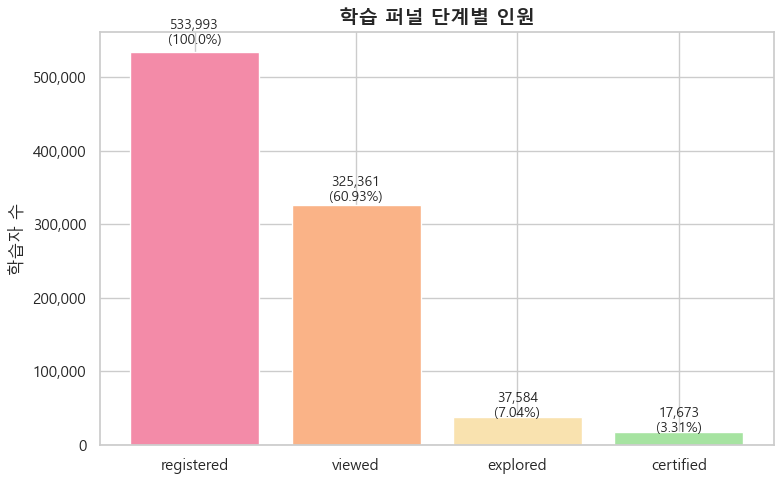

In [166]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#f38ba8', '#fab387', '#f9e2af', '#a6e3a1']
ax.bar(funnel_summary.index, funnel_summary['인원 수'], color=colors)

for i, (cnt, pct) in enumerate(zip(funnel_summary['인원 수'], funnel_rates)):
    ax.text(i, cnt + cnt*0.02, f"{cnt:,}\n({pct}%)", ha='center', fontsize=10)

ax.set_title('학습 퍼널 단계별 인원', fontsize=14, fontweight='bold')
ax.set_ylabel('학습자 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [167]:
stages = ['registered', 'viewed', 'explored', 'certified']
counts = [df[s].sum() for s in stages]

print("=== 단계별 전환율·이탈률 ===")
for i in range(1, len(stages)):
    conv = counts[i] / counts[i-1] * 100
    drop = 100 - conv
    print(f"{stages[i-1]:>12} → {stages[i]:<12}  전환 {conv:5.1f}%  |  이탈 {drop:5.1f}%")

print(f"\n{'전체 퍼널':>12} (Reg→Cert)   전환 {counts[-1]/counts[0]*100:5.1f}%")

=== 단계별 전환율·이탈률 ===
  registered → viewed        전환  60.9%  |  이탈  39.1%
      viewed → explored      전환  11.6%  |  이탈  88.4%
    explored → certified     전환  47.0%  |  이탈  53.0%

       전체 퍼널 (Reg→Cert)   전환   3.3%


In [220]:
behavior_cols = ['nevents', 'ndays_act', 'nchapters', 'nplay_video','nforum_posts']

null_zero = pd.DataFrame({
    'NULL 수': df[behavior_cols].isnull().sum(),
    'NULL(%)': (df[behavior_cols].isnull().mean() * 100).round(2),
    '0 수': (df[behavior_cols] == 0).sum(),
    '0(%)': ((df[behavior_cols] == 0).mean() * 100).round(2),
    '양수 수': (df[behavior_cols] > 0).sum(),
    '양수(%)': ((df[behavior_cols] > 0).mean() * 100).round(2)
})
display(null_zero)

,NULL 수,NULL(%),0 수,0(%),양수 수,양수(%)
nevents,1807,0.3400,91546,17.1400,440640,82.5200
ndays_act,1807,0.3400,91546,17.1400,440640,82.5200
nchapters,58210,10.9000,166598,31.2000,309185,57.9000
nplay_video,185071,34.6600,167537,31.3700,181385,33.9700
nforum_posts,0,0.0000,526589,98.6100,7404,1.3900


In [221]:
print("=== 행동 지표 기술통계 ===")
display(df[behavior_cols].describe().T.round(2))

# 평균 vs 중앙값 비교 → 왜도 판단
for col in behavior_cols:
    mean_val = df[col].mean()
    med_val = df[col].median()
    skew_val = df[col].skew()
    print(f"{col:>15}  평균={mean_val:8.2f}  중앙값={med_val:6.1f}  왜도={skew_val:6.2f}")

=== 행동 지표 기술통계 ===


,count,mean,std,min,25%,50%,75%,max
nevents,532186.0000,357.6800,1390.8600,0.0000,1.0000,11.0000,105.0000,197757.0000
ndays_act,532186.0000,4.8300,11.1500,0.0000,1.0000,1.0000,4.0000,205.0000
nchapters,475783.0000,2.6400,4.3500,0.0000,0.0000,1.0000,3.0000,48.0000
nplay_video,348922.0000,60.3100,314.9600,0.0000,0.0000,1.0000,20.0000,98517.0000
nforum_posts,533993.0000,0.0200,0.2500,0.0000,0.0000,0.0000,0.0000,20.0000


        nevents  평균=  357.68  중앙값=  11.0  왜도= 12.69
      ndays_act  평균=    4.83  중앙값=   1.0  왜도=  5.07
      nchapters  평균=    2.64  중앙값=   1.0  왜도=  3.37
    nplay_video  평균=   60.31  중앙값=   1.0  왜도=100.68
   nforum_posts  평균=    0.02  중앙값=   0.0  왜도= 23.56


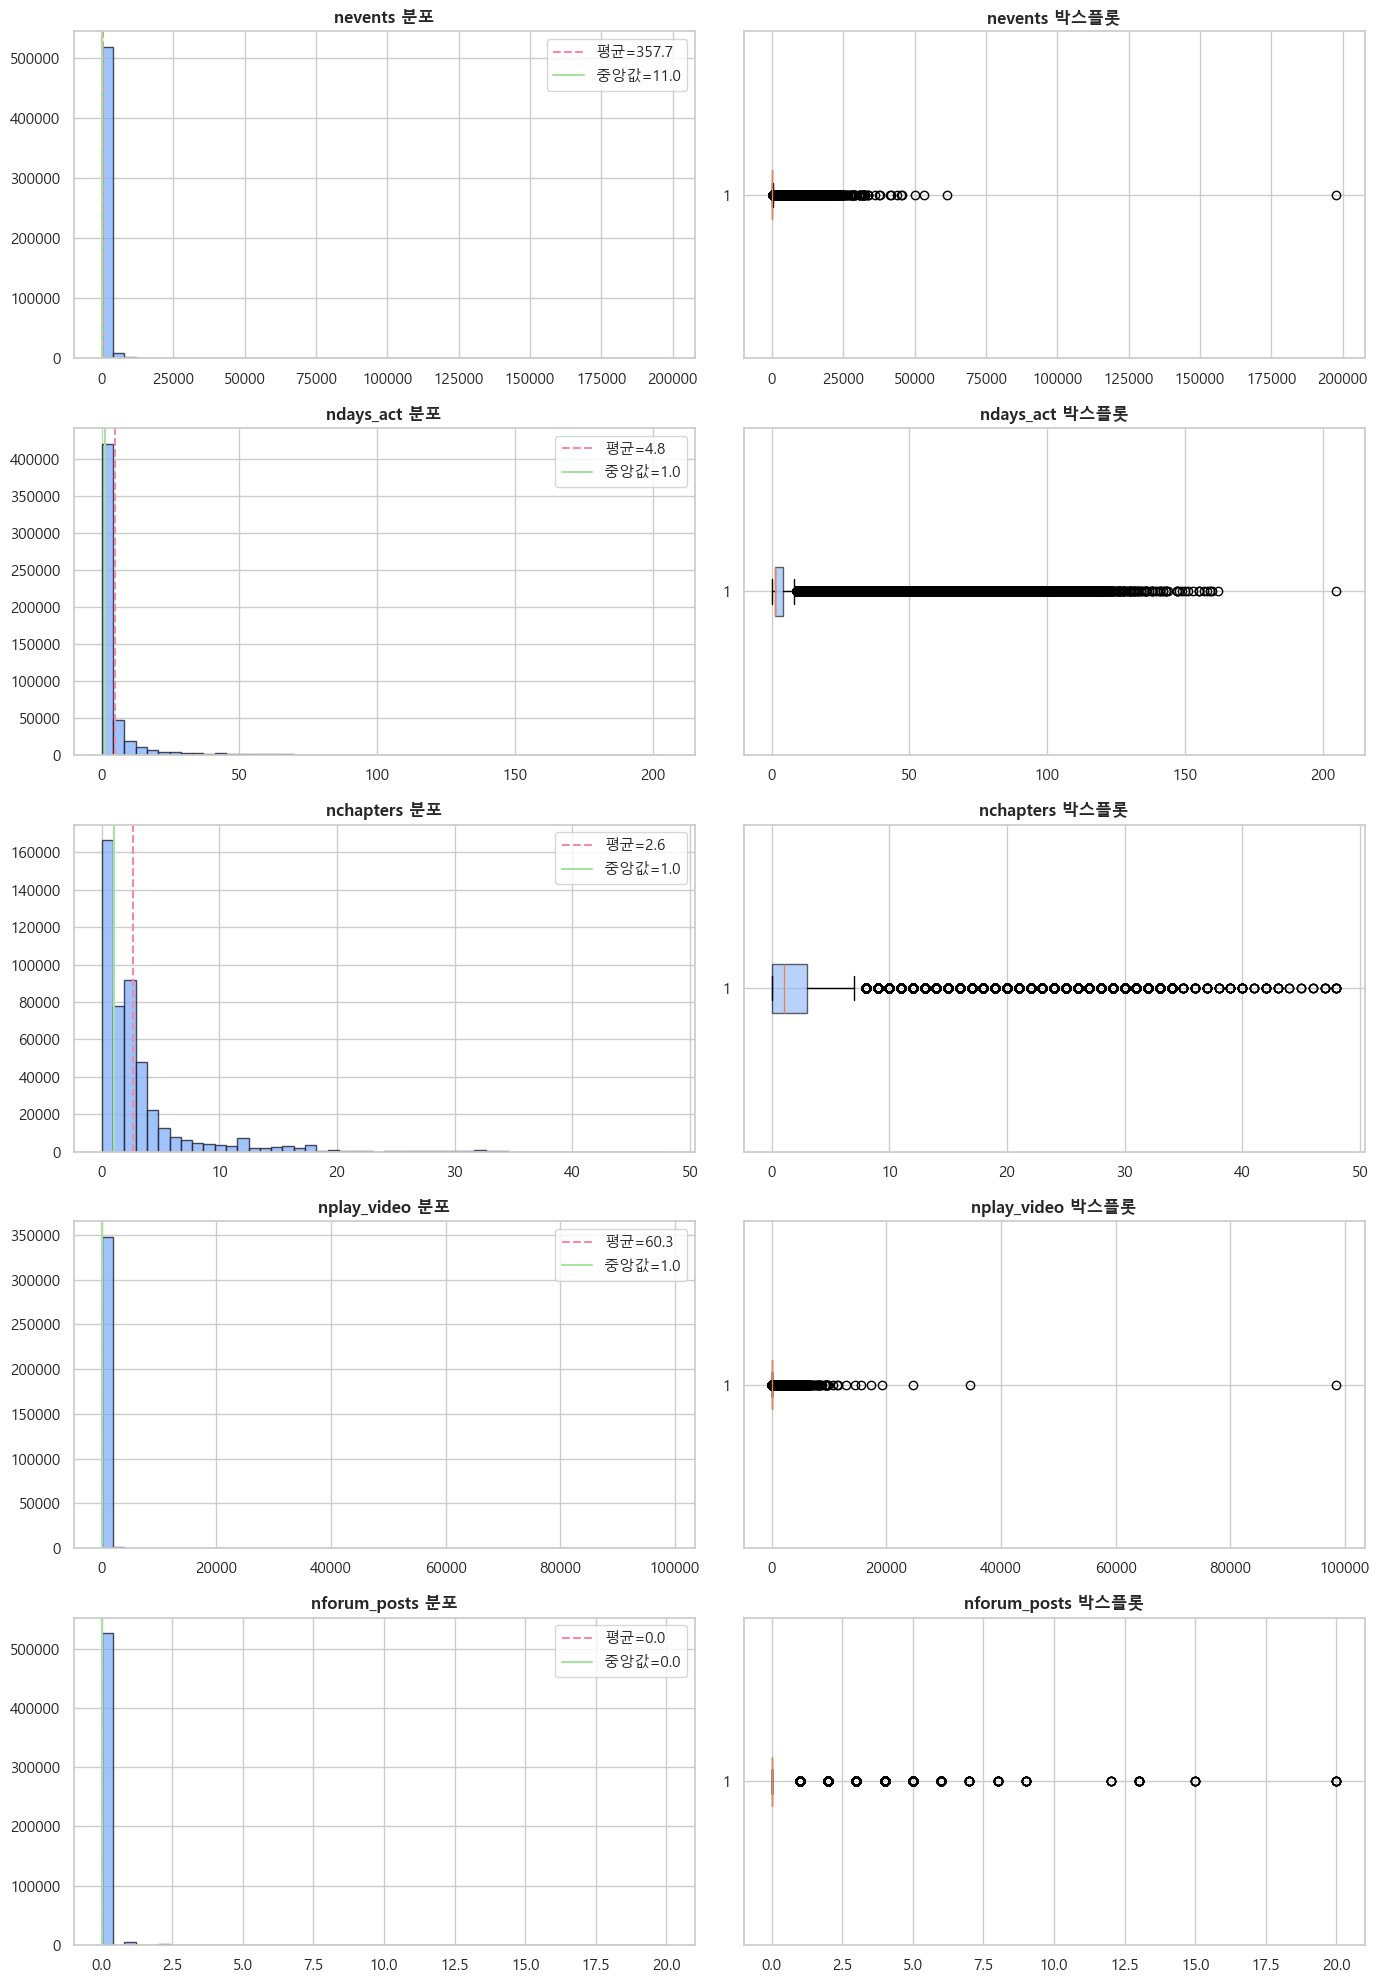

In [222]:
fig, axes = plt.subplots(len(behavior_cols), 2, figsize=(14, 4*len(behavior_cols)))

for i, col in enumerate(behavior_cols):
    data = df[col].dropna()

    # 히스토그램
    axes[i, 0].hist(data, bins=50, color='#89b4fa', edgecolor='#1e1e2e', alpha=0.8)
    axes[i, 0].axvline(data.mean(), color='#f38ba8', linestyle='--', label=f'평균={data.mean():.1f}')
    axes[i, 0].axvline(data.median(), color='#a6e3a1', linestyle='-', label=f'중앙값={data.median():.1f}')
    axes[i, 0].set_title(f'{col} 분포', fontweight='bold')
    axes[i, 0].legend()

    # 박스플롯
    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                        boxprops=dict(facecolor='#89b4fa', alpha=0.6))
    axes[i, 1].set_title(f'{col} 박스플롯', fontweight='bold')

plt.tight_layout()
plt.show()

In [171]:
print("=== grade 전체 기술통계 ===")
display(df['grade'].describe())

print(f"\ngrade NULL 수: {df['grade'].isnull().sum()}")
print(f"grade = 0 수:  {(df['grade'] == 0).sum()}")
print(f"grade > 0 수:  {(df['grade'] > 0).sum()}")

# grade > 0 서브셋
grade_pos = df.loc[df['grade'] > 0, 'grade']
print(f"\n=== grade > 0 기술통계 ===")
display(grade_pos.describe())

=== grade 전체 기술통계 ===


count   483483.0000
mean         0.0410
std          0.1655
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0100
Name: grade, dtype: float64


grade NULL 수: 50510
grade = 0 수:  409568
grade > 0 수:  73915

=== grade > 0 기술통계 ===


count   73915.0000
mean        0.2682
std         0.3438
min         0.0100
25%         0.0100
50%         0.0600
75%         0.5200
max         1.0100
Name: grade, dtype: float64

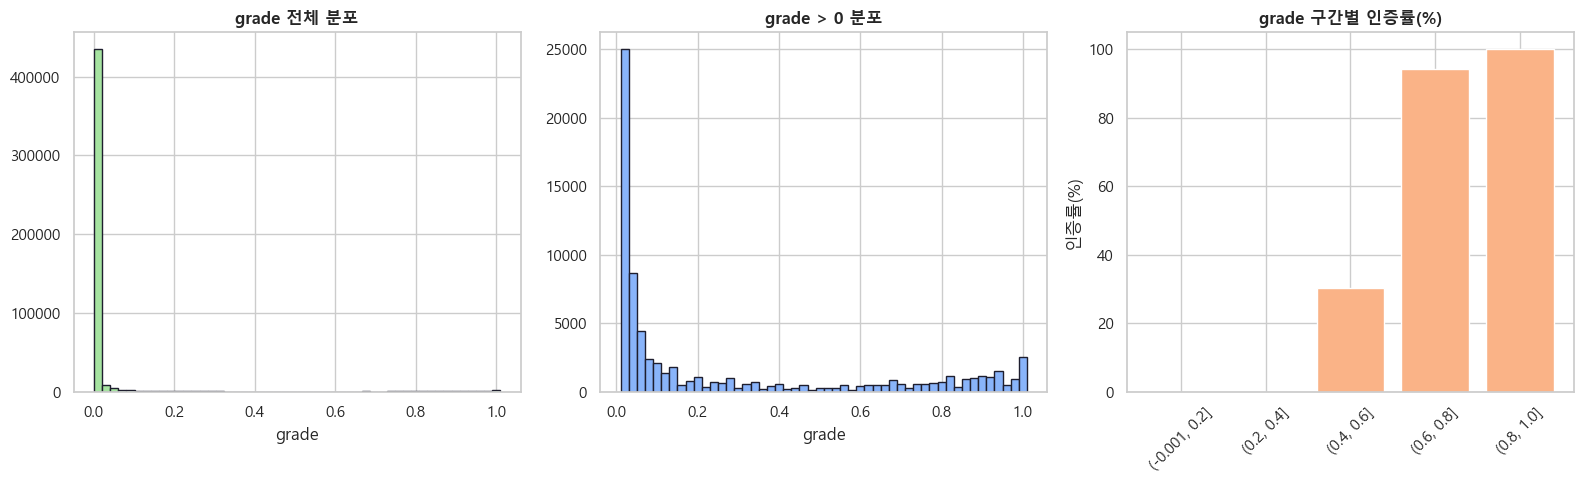

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 전체 grade 분포
axes[0].hist(df['grade'].dropna(), bins=50, color='#a6e3a1', edgecolor='#1e1e2e')
axes[0].set_title('grade 전체 분포', fontweight='bold')
axes[0].set_xlabel('grade')

# grade > 0 분포
axes[1].hist(grade_pos, bins=50, color='#89b4fa', edgecolor='#1e1e2e')
axes[1].set_title('grade > 0 분포', fontweight='bold')
axes[1].set_xlabel('grade')

# grade 구간별 인증률
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
df['grade_bin'] = pd.cut(df['grade'], bins=bins, include_lowest=True)
cert_by_grade = df.groupby('grade_bin', observed=True)['certified'].mean() * 100
axes[2].bar(range(len(cert_by_grade)), cert_by_grade.values, color='#fab387')
axes[2].set_xticks(range(len(cert_by_grade)))
axes[2].set_xticklabels([str(b) for b in cert_by_grade.index], rotation=45)
axes[2].set_title('grade 구간별 인증률(%)', fontweight='bold')
axes[2].set_ylabel('인증률(%)')

plt.tight_layout()
plt.show()

In [173]:
cert_counts = df['certified'].value_counts()
cert_rate = df['certified'].mean() * 100
print(f"인증 획득: {cert_counts.get(1, 0):,} ({cert_rate:.2f}%)")
print(f"미인증:    {cert_counts.get(0, 0):,} ({100-cert_rate:.2f}%)")

인증 획득: 17,673 (3.31%)
미인증:    516,320 (96.69%)


### 인구통계

In [174]:
display(df['gender'].value_counts(dropna=False))
print(f"\n결측률: {df['gender'].isnull().mean()*100:.2f}%")

gender
m          340309
f          120813
unknown     72863
o               8
Name: count, dtype: int64


결측률: 0.00%


In [175]:
print(df['LoE_DI'].value_counts(dropna=False))
print(f"\n결측률: {df['LoE_DI'].isnull().mean()*100:.2f}%")

LoE_DI
Bachelor's             183431
Secondary              139321
Master's               100554
unknown                 87859
Doctorate               11659
Less than Secondary     11169
Name: count, dtype: int64

결측률: 0.00%


count   452939.0000
mean      1985.3215
std          8.8579
min       1931.0000
25%       1982.0000
50%       1988.0000
75%       1991.0000
max       2013.0000
Name: YoB, dtype: float64

결측률: 15.18%
최솟값: 1931.0, 최댓값: 2013.0


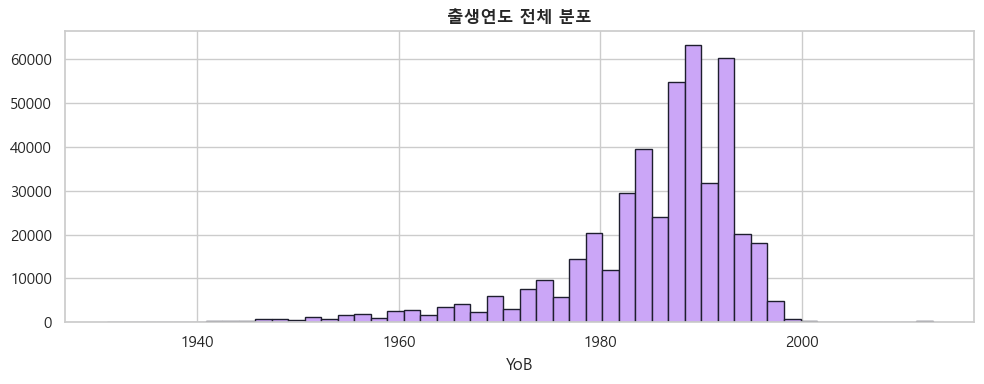

In [176]:
print(df['YoB'].describe())
print(f"\n결측률: {df['YoB'].isnull().mean()*100:.2f}%")
print(f"최솟값: {df['YoB'].min()}, 최댓값: {df['YoB'].max()}")

# 시각화를 위해 결측치만 제거 (특정 연도 필터링 없음)
yob_all = df['YoB'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(yob_all, bins=50, color='#cba6f7', edgecolor='#1e1e2e')
ax.set_title('출생연도 전체 분포', fontweight='bold')
ax.set_xlabel('YoB')
plt.tight_layout()
plt.show()


count   452939.0000
mean      1985.3215
std          8.8579
min       1931.0000
25%       1982.0000
50%       1988.0000
75%       1991.0000
max       2013.0000
Name: YoB, dtype: float64

결측률: 15.18%
최솟값: 1931.0, 최댓값: 2013.0

유효 범위(1940~2010) 비율: 84.7%


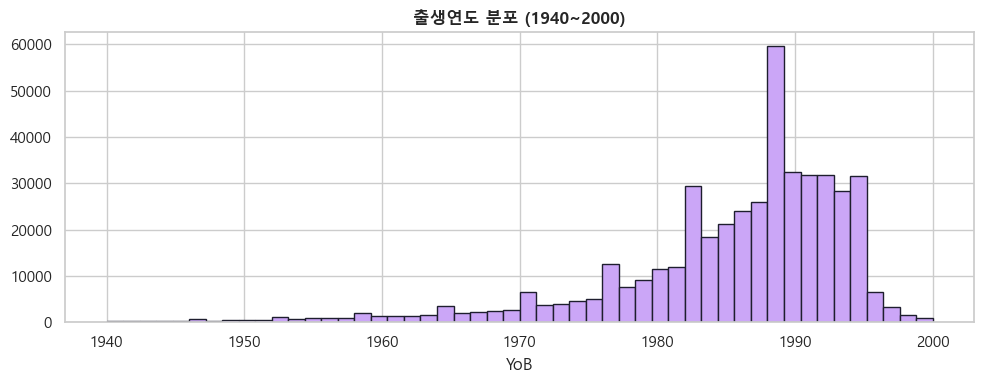

In [177]:
print(df['YoB'].describe())
print(f"\n결측률: {df['YoB'].isnull().mean()*100:.2f}%")
print(f"최솟값: {df['YoB'].min()}, 최댓값: {df['YoB'].max()}")

# 합리적 범위 내 분포
yob_valid = df.loc[df['YoB'].between(1940, 2000), 'YoB']
print(f"\n유효 범위(1940~2010) 비율: {len(yob_valid)/len(df)*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(yob_valid, bins=50, color='#cba6f7', edgecolor='#1e1e2e')
ax.set_title('출생연도 분포 (1940~2000)', fontweight='bold')
ax.set_xlabel('YoB')
plt.tight_layout()
plt.show()

In [178]:
print(f"고유 국가 수: {df['final_cc_cname_DI'].nunique()}")
print(f"결측률: {df['final_cc_cname_DI'].isnull().mean()*100:.2f}%")
print(f"\nTop 10 국가:")
display(df['final_cc_cname_DI'].value_counts().head(10))

고유 국가 수: 34
결측률: 0.00%

Top 10 국가:


final_cc_cname_DI
United States                     155616
India                              79044
Unknown/Other                      49202
Other Europe                       35434
Other Africa                       20942
United Kingdom                     19195
Brazil                             15978
Other Middle East/Central Asia     15380
Other South Asia                   11415
Canada                             10605
Name: count, dtype: int64

start_time_DI 범위: 2012-07-23 00:00:00 ~ 2013-09-07 00:00:00
last_event_DI 범위: 2012-07-24 00:00:00 ~ 2013-09-07 00:00:00


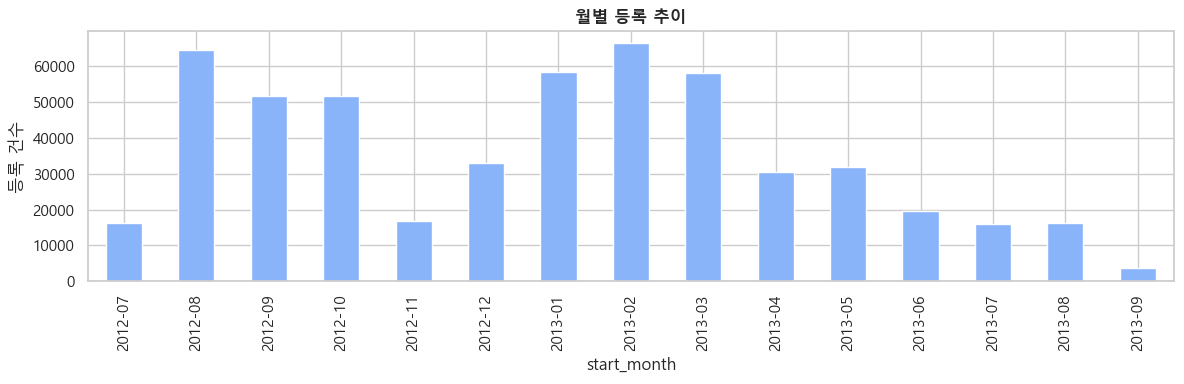

In [179]:
# 코스 시작 시점 분포
print(f"start_time_DI 범위: {df['start_time_DI'].min()} ~ {df['start_time_DI'].max()}")
print(f"last_event_DI 범위: {df['last_event_DI'].min()} ~ {df['last_event_DI'].max()}")

# 월별 등록 추이
df['start_month'] = df['start_time_DI'].dt.to_period('M')
monthly = df.groupby('start_month').size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind='bar', ax=ax, color='#89b4fa')
ax.set_title('월별 등록 추이', fontweight='bold')
ax.set_ylabel('등록 건수')
plt.tight_layout()
plt.show()

=== 학습 기간(일) 기술통계 ===
count   533993.0000
mean        40.0711
std         68.0595
min          0.0000
25%          0.0000
50%          1.0000
75%         54.0000
max        409.0000
Name: duration, dtype: float64


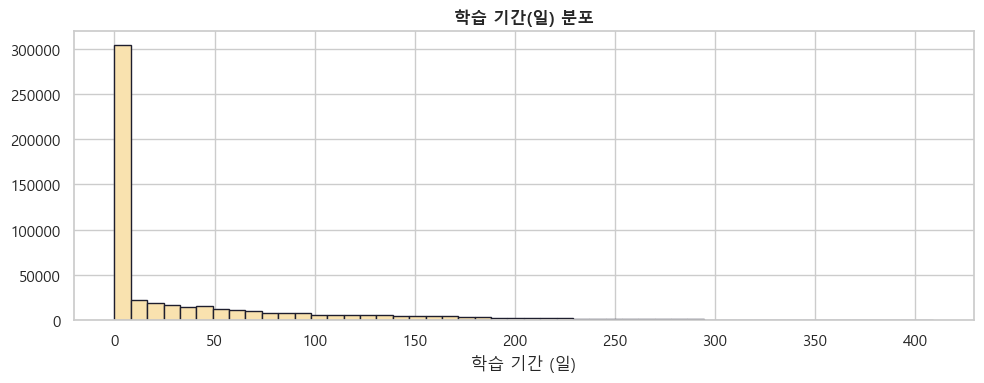

In [180]:
# 학습 기간 = 마지막 활동일 - 코스 시작일
df['duration'] = (df['last_event_DI'] - df['start_time_DI']).dt.days

print("=== 학습 기간(일) 기술통계 ===")
print(df['duration'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
valid_duration = df['duration'].dropna()
valid_duration = valid_duration[valid_duration >= 0]
ax.hist(valid_duration, bins=50, color='#f9e2af', edgecolor='#1e1e2e')
ax.set_title('학습 기간(일) 분포', fontweight='bold')
ax.set_xlabel('학습 기간 (일)')
plt.tight_layout()
plt.show()

,등록자수
count,16.0000
mean,33374.5625
std,25269.1657
min,5325.0000
25%,18064.5000
50%,25517.0000
75%,43495.5000
max,100467.0000


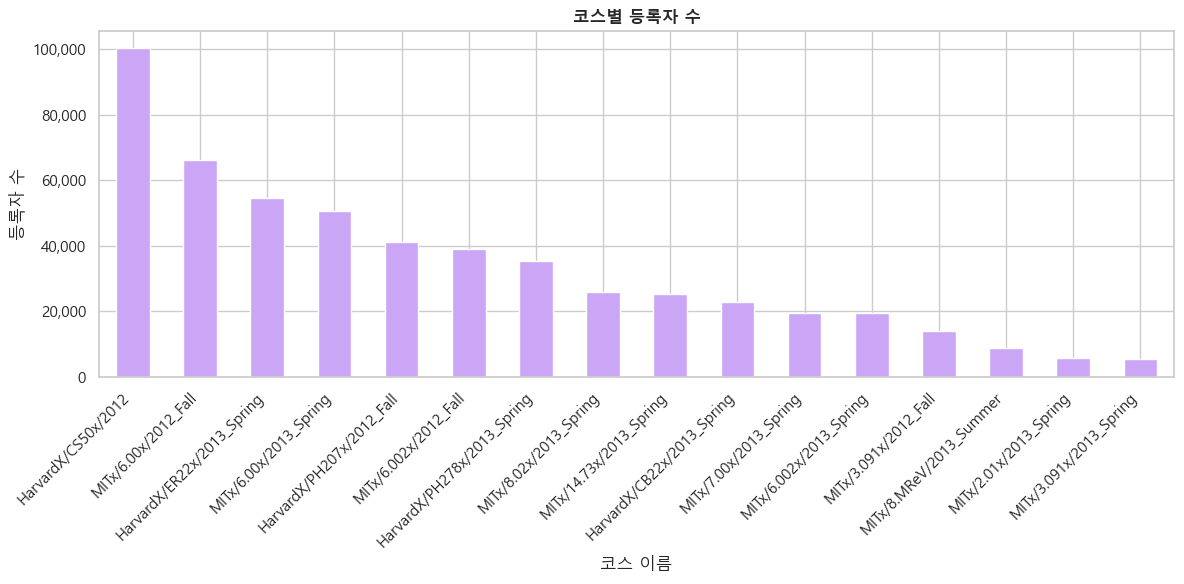

In [181]:
# 코스별 등록자 수 분포
course_size = df.groupby('course_id').size().reset_index(name='등록자수')
display(course_size.describe())

# 등록자 수 기준으로 내림차순 정렬
course_size_sorted = course_size.sort_values(by='등록자수', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6)) # 코스명이 길 수 있으므로 가로/세로 크기 조정
course_size_sorted.plot(
    kind='bar', 
    x='course_id', 
    y='등록자수', 
    ax=ax, 
    color='#cba6f7', 
    legend=False
)

ax.set_title('코스별 등록자 수', fontweight='bold')
ax.set_xlabel('코스 이름')
ax.set_ylabel('등록자 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 글씨가 겹치지 않게 45도 기울이고 오른쪽 정렬
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [182]:
# 코스별 퍼널 도달율
funnel_by_course = df.groupby('course_id')[['registered', 'viewed', 'explored', 'certified']].agg(
    total=('registered', 'sum'),
    viewed_rate=('viewed', 'mean'),
    explored_rate=('explored', 'mean'),
    cert_rate=('certified', 'mean')
)

# 재구성
funnel_by_course = df.groupby('course_id').agg(
    total=('registered', 'sum'),
    viewed_rate=('viewed', 'mean'),
    explored_rate=('explored', 'mean'),
    cert_rate=('certified', 'mean')
).round(4)

funnel_by_course[['viewed_rate', 'explored_rate', 'cert_rate']] *= 100
funnel_by_course.columns = ['등록자수', 'Viewed(%)', 'Explored(%)', 'Certified(%)']
display(funnel_by_course.sort_values('Explored(%)', ascending=False))

,등록자수,Viewed(%),Explored(%),Certified(%)
course_id,,,,
MITx/14.73x/2013_Spring,25148,62.5100,11.6600,8.2900
HarvardX/PH207x/2012_Fall,41110,58.9000,10.5100,4.4800
MITx/2.01x/2013_Spring,5546,69.6900,10.1000,4.4500
HarvardX/CS50x/2012,100467,41.1800,8.9300,1.2800
MITx/7.00x/2013_Spring,19558,66.8200,7.9000,4.2000
MITx/6.002x/2012_Fall,38935,64.0100,7.7200,4.4900
MITx/8.02x/2013_Spring,25886,77.0700,6.9500,3.1800
HarvardX/ER22x/2013_Spring,54636,58.7700,6.4600,4.2900
MITx/3.091x/2012_Fall,13926,50.2600,6.4200,4.5400


In [183]:
# 1. 코스별 각 단계 인원수 총합 구하기
funnel_counts = df.groupby('course_id')[['registered', 'viewed', 'explored', 'certified']].sum()

# 2. 직전 단계 대비 퍼널 전환율 계산을 담을 새로운 데이터프레임 생성
funnel_conversion = pd.DataFrame()
funnel_conversion['등록자수'] = funnel_counts['registered']

# 단계 1 전환율: Registered(등록) -> Viewed(조회)
funnel_conversion['가입->조회_전환율(%)'] = (funnel_counts['viewed'] / funnel_counts['registered'] * 100).round(2)

# 단계 2 전환율: Viewed(조회) -> Explored(탐색)
# (만약 특정 코스에 viewed 인원이 0명이라서 발생하는 에러나 NaN(결측치) 방지를 위해 fillna(0) 추가)
funnel_conversion['조회->탐색_전환율(%)'] = (funnel_counts['explored'] / funnel_counts['viewed'] * 100).fillna(0).round(2)

# 단계 3 전환율: Explored(탐색) -> Certified(수료)
funnel_conversion['탐색->수료_전환율(%)'] = (funnel_counts['certified'] / funnel_counts['explored'] * 100).fillna(0).round(2)

# (선택) 최종 달성률: 처음 등록해서 수료까지 간 비율
funnel_conversion['최종_달성률(%)'] = (funnel_counts['certified'] / funnel_counts['registered'] * 100).round(2)

# 결과 출력 (최종 달성률 기준으로 내림차순 정렬)
display(funnel_conversion.sort_values('조회->탐색_전환율(%)', ascending=False))


,등록자수,가입->조회_전환율(%),조회->탐색_전환율(%),탐색->수료_전환율(%),최종_달성률(%)
course_id,,,,,
HarvardX/CS50x/2012,100467,41.1800,21.6900,14.3300,1.2800
MITx/14.73x/2013_Spring,25148,62.5100,18.6600,71.0500,8.2900
HarvardX/PH207x/2012_Fall,41110,58.9000,17.8400,42.5800,4.4800
MITx/2.01x/2013_Spring,5546,69.6900,14.4900,44.1100,4.4500
MITx/3.091x/2012_Fall,13926,50.2600,12.7700,70.6900,4.5400
MITx/6.002x/2012_Fall,38935,64.0100,12.0600,58.1800,4.4900
MITx/7.00x/2013_Spring,19558,66.8200,11.8300,53.1000,4.2000
HarvardX/ER22x/2013_Spring,54636,58.7700,10.9900,66.4200,4.2900
MITx/6.00x/2012_Fall,66124,62.5600,10.1100,59.2000,3.7400


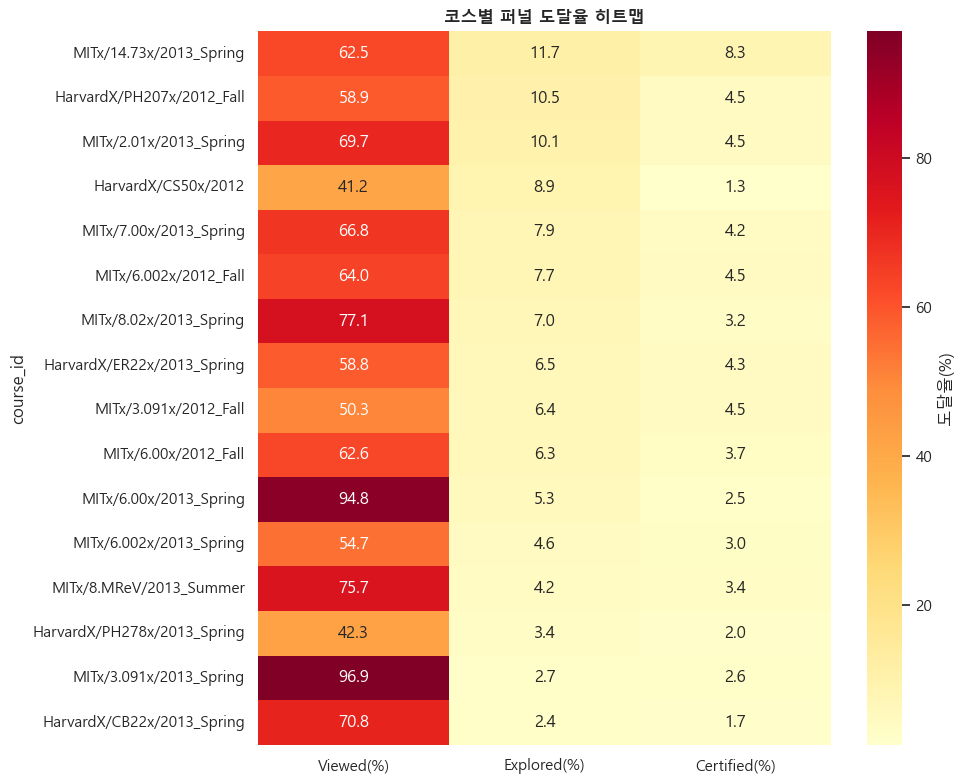

In [184]:
funnel_rates = funnel_by_course[['Viewed(%)', 'Explored(%)', 'Certified(%)']]

fig, ax = plt.subplots(figsize=(10, max(6, len(funnel_rates)*0.5)))
sns.heatmap(funnel_rates.sort_values('Explored(%)', ascending=False),
            annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '도달율(%)'})
ax.set_title('코스별 퍼널 도달율 히트맵', fontweight='bold')
plt.tight_layout()
plt.show()

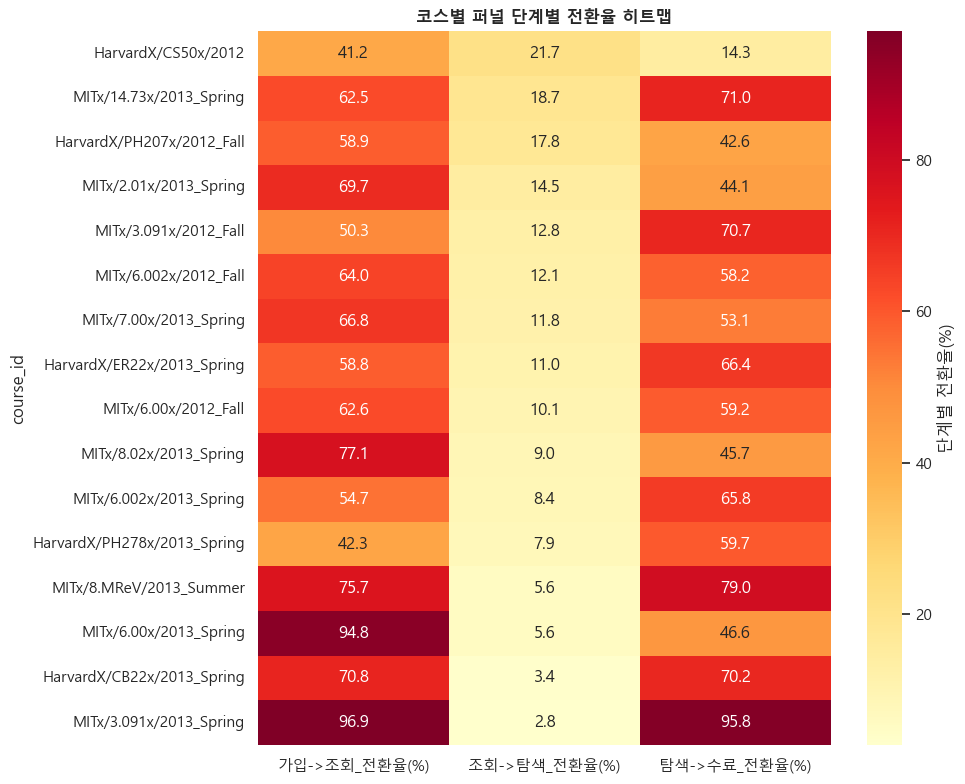

In [185]:
# 변수에서 각 단계별 진짜 전환율 컬럼만 선택
# (만들어 둔 funnel_conversion 데이터프레임 사용)
funnel_rates = funnel_conversion[['가입->조회_전환율(%)', '조회->탐색_전환율(%)', '탐색->수료_전환율(%)']]

fig, ax = plt.subplots(figsize=(10, max(6, len(funnel_rates) * 0.5)))

# 마지막 퍼널 구간인 '조회->탐색_전환율(%)' 기준으로 가장 이탈이 적은(수료 전환이 높은) 코스부터 표기
sns.heatmap(
    funnel_rates.sort_values('조회->탐색_전환율(%)', ascending=False),
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd', 
    ax=ax,
    cbar_kws={'label': '단계별 전환율(%)'}
)

# 제목 및 레이블 업데이트
ax.set_title('코스별 퍼널 단계별 전환율 히트맵', fontweight='bold')
plt.tight_layout()
plt.show()


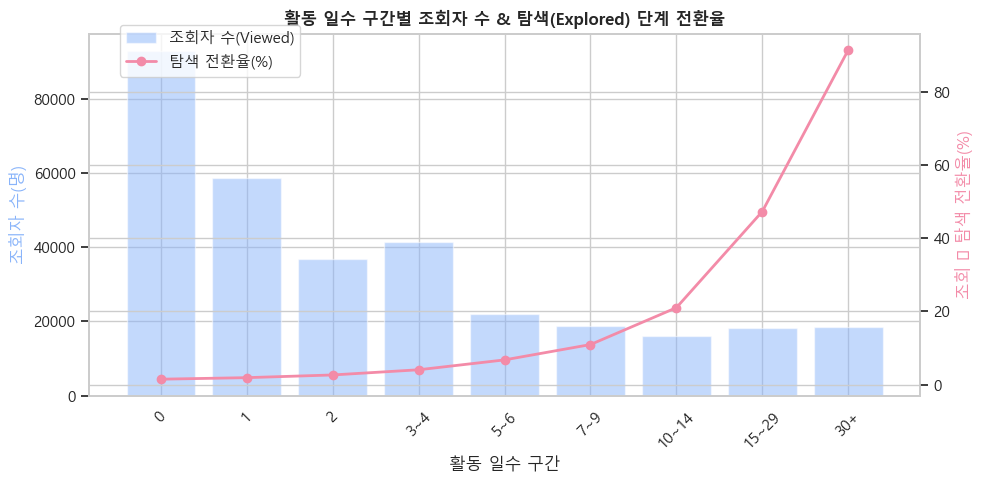

In [186]:
# 활동일수 구간별 '조회 -> 탐색' 퍼널 전환율
bins_ndays = [0, 1, 2, 3, 5, 7, 10, 15, 30, 999]
labels_ndays = ['0', '1', '2', '3~4', '5~6', '7~9', '10~14', '15~29', '30+']
df['ndays_bin'] = pd.cut(df['ndays_act'].fillna(-1), bins=[-1]+bins_ndays, labels=['NULL']+labels_ndays)

# 전환율(Viewed -> Explored) 계산을 위해, 조회를 한 번이라도 한 사람(viewed == 1)만 추출
viewed_df = df[(df['ndays_bin'] != 'NULL') & (df['viewed'] == 1)]

# 구간별 총 조회자 수(count)와 탐색 전환율(explore_rate) 산출
explore_by_ndays = viewed_df.groupby('ndays_bin', observed=True).agg(
    count=('viewed', 'size'),          # 해당 구간의 총 조회자 수 분모 적용
    explore_rate=('explored', 'mean')  # 조회자 중 탐색한 사람 비율 (전환율)
)
explore_by_ndays['explore_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# 막대 그래프 (조회자 수 분모 분포)
ax1.bar(range(len(explore_by_ndays)), explore_by_ndays['count'], color='#89b4fa', alpha=0.5, label='조회자 수(Viewed)')
# 꺾은선 그래프 (View -> Explore 전환율)
ax2.plot(range(len(explore_by_ndays)), explore_by_ndays['explore_rate'], color='#f38ba8', marker='o',
         linewidth=2, label='탐색 전환율(%)')

ax1.set_xticks(range(len(explore_by_ndays)))
ax1.set_xticklabels(explore_by_ndays.index, rotation=45)
ax1.set_xlabel('활동 일수 구간')
ax1.set_ylabel('조회자 수(명)', color='#89b4fa')
ax2.set_ylabel('조회 ➔ 탐색 전환율(%)', color='#f38ba8')
ax1.set_title('활동 일수 구간별 조회자 수 & 탐색(Explored) 단계 전환율', fontweight='bold')

# 범례 위치 조정 
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()


### 행동 지표와 exp 전환율의 상관행렬

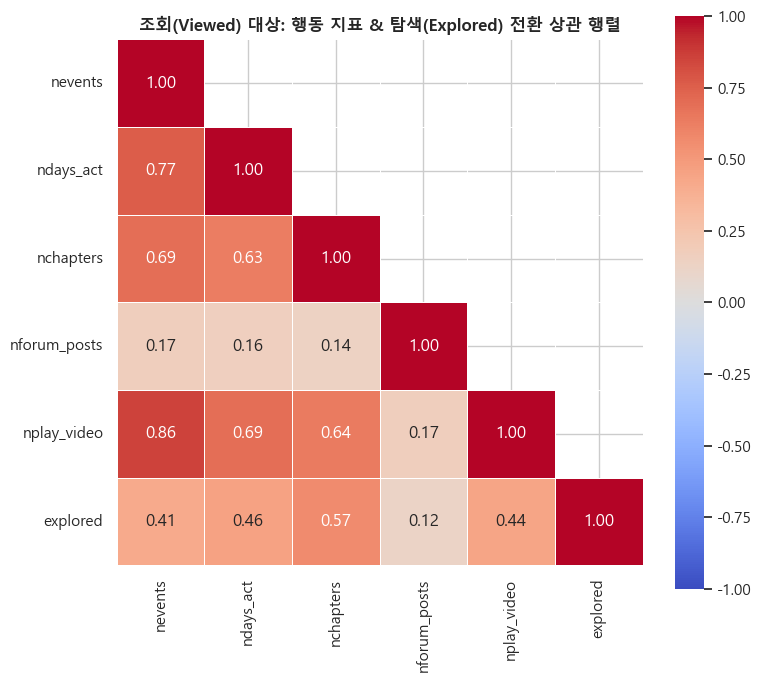

In [204]:
# '조회(View)'를 한 학습자를 기준으로 필터링하여 정확한 상관성을 도출
viewed_df = df[df['viewed'] == 1].copy()

# 'grade' 대신 'explored' 여부 추가 (이진형 데이터 0 or 1 상관계수 도출)
behavior_achievement = ['nevents', 'ndays_act', 'nchapters', 'nforum_posts', 'nplay_video','explored']
corr_matrix = viewed_df[behavior_achievement].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f',
    cmap='coolwarm', 
    center=0, 
    ax=ax, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.5
)

# 차트 제목 업데이트
ax.set_title('조회(Viewed) 대상: 행동 지표 & 탐색(Explored) 전환 상관 행렬', fontweight='bold')
plt.tight_layout()
plt.show()


- nchapter가 가장 높긴 하지만, nchapter는 exp 전환의 조건 중 하나로 당연히 상관계수가 높을 수 밖에 없음
- ndays_act로 확인

# ndays_act & exp 전환율 상관계수(0.46)
- 통계검정 시행

📊 통계 검정 계획: 활동 일수(ndays_act)는 탐색(Explored) 전환에 유의미한 차이를 보일까?
1장. 가설 설정 (Hypothesis)
모수: 코스를 1번이라도 클릭해 본(viewed == 1) 학습자 집단 전체

귀무가설 ($H_0$): 단순 접속자(Explored=0)와 탐색 전환자(Explored=1) 간에 ndays_act(총 활동 일수)의 차이가 없다.
대립가설 ($H_1$): 탐색 전환자(Explored=1)가 단순 접속자(0)보다 ndays_act가 유의미하게 더 길다. (우측 단측 검정)

2장. 데이터 특성 및 가정 검토 (Assumptions)
왜도가 극도로 높아, 정규성을 만족하지 않으므로 순위 검정 시행

3장. 검정 방법론: 맨-휘트니 U 검정 (Mann-Whitney U Test)
서로 다른 두 집단(전환 성공 vs 실패)의 중앙값 혹은 순위 분포가 차이 나는지 검증할 때 쓰이는 가장 확실한 비모수 검정 기법입니다.

In [188]:
# 1. 대상 그룹 분리: 조회를 한 번이라도 한 사람(viewed == 1) 중 결측치 제거
group_0 = df[(df['viewed'] == 1) & (df['explored'] == 0)]['ndays_act'].dropna()
group_1 = df[(df['viewed'] == 1) & (df['explored'] == 1)]['ndays_act'].dropna()

# --- 기술 통계 (평균과 중앙값 차이 직관적 확인) ---
print(f"[단순 조회자(0)] 평균: {group_0.mean():.1f}일 | 중앙값: {group_0.median():.0f}일 | 총 {len(group_0):,}명")
print(f"[탐색 전환자(1)] 평균: {group_1.mean():.1f}일 | 중앙값: {group_1.median():.0f}일 | 총 {len(group_1):,}명")

# 2. 비모수 검정: Mann-Whitney U test (탐색집단의 활동일수가 '더 큰가?')
# 💡 여기서 반환되는 stat 변수는 group_1을 기준으로 산출된 U 통계량(U1)입니다.
stat, p_val = stats.mannwhitneyu(group_1, group_0, alternative='greater')

print(f"\n📈 Mann-Whitney U 통계량: {stat}")
print(f"📉 P-value (유의확률): {p_val:.5e}")

if p_val < 0.05:
    print("\n👉 [결론 도출] 통계적으로 매우 유의미합니다! (p < 0.05)")
    print("탐색 집단(Explore=1)으로 전환된 사람들의 플랫폼 '활동 일수(ndays_act)'가 유의미하게 더 깁니다.")
else:
    print("\n👉 [결론 도출] 통계적으로 유의미한 차이가 없습니다.")


# 3. 비모수 환경에 완벽하게 호환되는 효과 크기: Rank-Biserial Correlation (r_rb) 산출
n1 = len(group_1)
n0 = len(group_0)

# 공식: r_rb = (2 * U1) / (n1 * n0) - 1
# 결과값은 -1 ~ 1 사이로 도출되며, 양수면 group_1(탐색 전환자)의 순위가 더 높음을 의미합니다.
r_rb = (2 * stat) / (n1 * n0) - 1
abs_r = abs(r_rb)

print(f"\n📊 비모수적 효과 크기(Rank-Biserial Correlation): {r_rb:.3f}")

# 효과 크기 가이드라인 (비모수 상관계수 r 기준: 0.1=Small, 0.3=Medium, 0.5=Large)
if abs_r >= 0.5:
    print("   👉 효과 크기가 '매우 큼(Large)' 수준입니다. 1%의 헤비 유저들(아웃라이어) 때문이 아니라, 대다수 탐색 전환자들의 출석 일수 등수가 단순 조회자들의 등수를 압도하고 있습니다.")
elif abs_r >= 0.3:
    print("   👉 효과 크기가 '중간(Medium)' 수준이며, 탐색 전환율과 꽤 선명한 연관성을 가집니다.")
elif abs_r >= 0.1:
    print("   👉 효과 크기가 '작음(Small)' 수준입니다. 통계적으로는 유의미하나, 다른 요인들도 크게 작용하고 있습니다.")
else:
    print("   👉 효과 크기가 '미미함(Trivial)' 수준입니다. 워낙 사람 수가 많아 p-value가 유의미하게 떴을 뿐입니다.")


[단순 조회자(0)] 평균: 4.2일 | 중앙값: 2일 | 총 285,970명
[탐색 전환자(1)] 평균: 32.7일 | 중앙값: 27일 | 총 37,584명

📈 Mann-Whitney U 통계량: 9742140489.0
📉 P-value (유의확률): 0.00000e+00

👉 [결론 도출] 통계적으로 매우 유의미합니다! (p < 0.05)
탐색 집단(Explore=1)으로 전환된 사람들의 플랫폼 '활동 일수(ndays_act)'가 유의미하게 더 깁니다.

📊 비모수적 효과 크기(Rank-Biserial Correlation): 0.813
   👉 효과 크기가 '매우 큼(Large)' 수준입니다. 1%의 헤비 유저들(아웃라이어) 때문이 아니라, 대다수 탐색 전환자들의 출석 일수 등수가 단순 조회자들의 등수를 압도하고 있습니다.


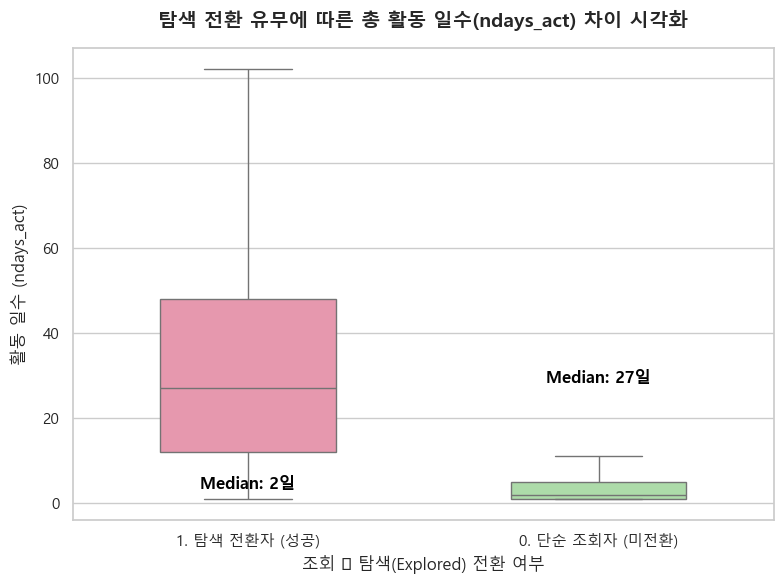

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화를 위한 데이터 준비 (viewed == 1 인원만)
plot_df = df[df['viewed'] == 1].copy()

# 보기 좋게 라벨 달기
plot_df['explored_label'] = plot_df['explored'].map({
    0: '0. 단순 조회자 (미전환)', 
    1: '1. 탐색 전환자 (성공)'
})

fig, ax = plt.subplots(figsize=(8, 6))

# 2. 박스 플롯 시각화 (이상치 제거로 찌그러짐 방지)
sns.boxplot(
    data=plot_df, 
    x='explored_label', 
    y='ndays_act', 
    palette=['#f38ba8', '#a6e3a1'],  # 붉은색(실패) vs 녹색(성공)
    showfliers=False,                # 극단적인 출석왕(이상치) 점들을 지워줌
    width=0.5,
    ax=ax
)

# 3. 비모수 검정의 핵심인 '중앙값(Median)'을 차트 위에 숫자로 찍어주기
medians = plot_df.groupby('explored_label')['ndays_act'].median()
for i, median_val in enumerate(medians):
    ax.text(
        i, median_val + 0.3,             # 박스 중앙값 선에서 살짝 위에 표기
        f'Median: {median_val:.0f}일', 
        ha='center', va='bottom', 
        fontweight='bold', color='black', fontsize=12
    )

# 4. 축과 타이틀 디자인 설정
ax.set_title('탐색 전환 유무에 따른 총 활동 일수(ndays_act) 차이 시각화', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('조회 👉 탐색(Explored) 전환 여부', fontsize=12)
ax.set_ylabel('활동 일수 (ndays_act)', fontsize=12)

plt.tight_layout()
plt.show()


■ 정규성(Normality) 통계 검정 결과 ■
[단순 조회자(0)] p-value: 0.00000e+00 (N=285,970)
[탐색 전환자(1)] p-value: 0.00000e+00 (N=37,584)
* 대용량 데이터 특성상 p-value가 0.05 미만으로 나와 '정규성 기각'이 뜰 확률이 높습니다.
-------------------------------------------------------


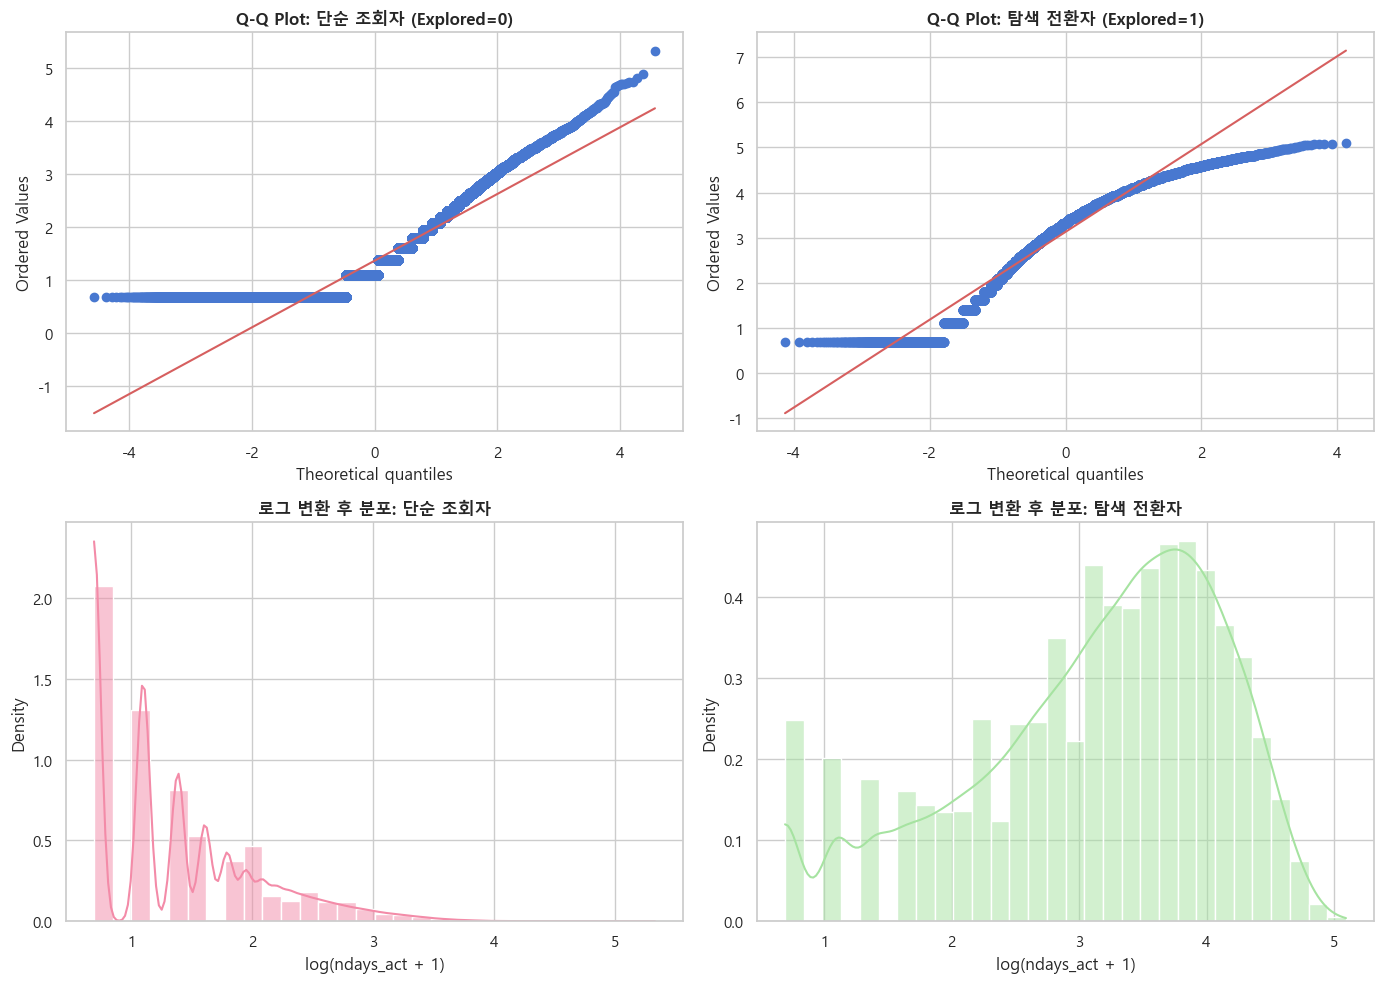

In [190]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 대상 추출 및 로그 변환 (log1p 적용)
# (viewed==1 대상으로 분리)
log_ndays_0 = np.log1p(df[(df['viewed'] == 1) & (df['explored'] == 0)]['ndays_act'].dropna())
log_ndays_1 = np.log1p(df[(df['viewed'] == 1) & (df['explored'] == 1)]['ndays_act'].dropna())

# 2. 정규성 통계 검정 (수만 개 이상의 대용량 데이터에 적합한 D'Agostino's K-squared test)
# H0(귀무가설): 데이터가 정규분포를 따른다.
stat_0, p_0 = stats.normaltest(log_ndays_0)
stat_1, p_1 = stats.normaltest(log_ndays_1)

print("■ 정규성(Normality) 통계 검정 결과 ■")
print(f"[단순 조회자(0)] p-value: {p_0:.5e} (N={len(log_ndays_0):,})")
print(f"[탐색 전환자(1)] p-value: {p_1:.5e} (N={len(log_ndays_1):,})")
print("* 대용량 데이터 특성상 p-value가 0.05 미만으로 나와 '정규성 기각'이 뜰 확률이 높습니다.")
print("-" * 55)

# 3. 데이터 변환 형태 눈으로 확인 (시각화)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3-1. Q-Q Plot: 파란색 점들이 빨간색 대각선에 일치할수록 완벽한 정규분포를 의미
stats.probplot(log_ndays_0, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot: 단순 조회자 (Explored=0)', fontweight='bold')

stats.probplot(log_ndays_1, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: 탐색 전환자 (Explored=1)', fontweight='bold')

# 3-2. 히스토그램 + KDE 커널밀도곡선: 실제 종 모양(Bell Curve) 유무 확인
sns.histplot(log_ndays_0, kde=True, bins=30, ax=axes[1, 0], color='#f38ba8', stat='density')
axes[1, 0].set_title('로그 변환 후 분포: 단순 조회자', fontweight='bold')
axes[1, 0].set_xlabel('log(ndays_act + 1)')

sns.histplot(log_ndays_1, kde=True, bins=30, ax=axes[1, 1], color='#a6e3a1', stat='density')
axes[1, 1].set_title('로그 변환 후 분포: 탐색 전환자', fontweight='bold')
axes[1, 1].set_xlabel('log(ndays_act + 1)')

plt.tight_layout()
plt.show()


In [191]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. 대상 그룹 분리: 조회를 한 번이라도 한 사람(viewed == 1) 한정 
viewed_df = df[df['viewed'] == 1].copy()

# 2. 분할표(Contingency Table) 작성
# (각 course_id 마다 탐색 전환(1) 성공자와 미전환(0) 실패자의 인원수 표 생성)
contingency_table = pd.crosstab(viewed_df['course_id'], viewed_df['explored'])

# 3. 카이제곱 독립성 검정 
# (H0: course_id와 전환율은 상관없이 똑같다. / H1: course_id별로 전환율이 유의미하게 튄다.)
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("\n■ 카이제곱(Chi-Square) 통계 검정 결과 ■")
print(f"📈 카이제곱 통계량: {chi2:.2f}")
print(f"📉 P-value (유의확률): {p_val:.5e}")

if p_val < 0.05:
    print("👉 결론: 통계적으로 매우 유의미합니다! 어느 '코스(과목)'를 선택했느냐에 따라 탐색(Explored) 전환율이 통계적으로 확실히 다릅니다.")
else:
    print("👉 결론: 코스별 전환율 패턴 양상에 큰 차이가 없습니다.")

print("-" * 55)

# 4. 실질적 차이 크기를 보는 피살기: 크래머 V (Cramer's V) 
# (0에 가까우면 차이 없음, 1에 가까우면 과목이 전환율을 100% 지배함)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"📊 실무적 효과 크기(Cramer's V): {cramers_v:.3f}")
if cramers_v >= 0.5:
    print("  👉 [효과 큼] 각 과목의 난이도, 강사, 퀄리티 등의 편차가 전환율을 '매우 강력하게' 뒤흔들고 있습니다.")
elif cramers_v >= 0.3:
    print("  👉 [효과 중간] 과목의 종류가 수강생들의 다음 단계 전환 여부에 '적당히 꽤 높은' 연관성을 줍니다.")
elif cramers_v >= 0.1:
    print("  👉 [효과 약함] 통계적으로 차이는 증명되었지만, 실무적으로 봤을 때 완전히 '강한' 편차 수준은 아닙니다.")
else:
    print("  👉 [효과 미미함] 코스 간 차이가 있긴 하지만, 사실상 신경 쓸 변화가 아닙니다. 다른 요인을 찾아봐야 합니다.")



■ 카이제곱(Chi-Square) 통계 검정 결과 ■
📈 카이제곱 통계량: 9789.51
📉 P-value (유의확률): 0.00000e+00
👉 결론: 통계적으로 매우 유의미합니다! 어느 '코스(과목)'를 선택했느냐에 따라 탐색(Explored) 전환율이 통계적으로 확실히 다릅니다.
-------------------------------------------------------
📊 실무적 효과 크기(Cramer's V): 0.173
  👉 [효과 약함] 통계적으로 차이는 증명되었지만, 실무적으로 봤을 때 완전히 '강한' 편차 수준은 아닙니다.


# nevents & exp 전환율

In [215]:
# 1. 대상 그룹 분리: 조회를 한 번이라도 한 사람(viewed == 1) 중 결측치 제거
group_0 = df[(df['viewed'] == 1) & (df['explored'] == 0)]['nevents'].dropna()
group_1 = df[(df['viewed'] == 1) & (df['explored'] == 1)]['nevents'].dropna()

# --- 기술 통계 (평균과 중앙값 차이 직관적 확인) ---
print(f"[단순 조회자(0)] 평균: {group_0.mean():.1f}일 | 중앙값: {group_0.median():.0f}일 | 총 {len(group_0):,}명")
print(f"[탐색 전환자(1)] 평균: {group_1.mean():.1f}일 | 중앙값: {group_1.median():.0f}일 | 총 {len(group_1):,}명")

# 2. 비모수 검정: Mann-Whitney U test (탐색집단의 활동일수가 '더 큰가?')
# 💡 여기서 반환되는 stat 변수는 group_1을 기준으로 산출된 U 통계량(U1)입니다.
stat, p_val = stats.mannwhitneyu(group_1, group_0, alternative='greater')

print(f"\n📈 Mann-Whitney U 통계량: {stat}")
print(f"📉 P-value (유의확률): {p_val:.5e}")

if p_val < 0.05:
    print("\n👉 [결론 도출] 통계적으로 매우 유의미합니다! (p < 0.05)")
    print("탐색 집단(Explore=1)으로 전환된 사람들의 플랫폼 '활동 일수(nevents)'가 유의미하게 더 깁니다.")
else:
    print("\n👉 [결론 도출] 통계적으로 유의미한 차이가 없습니다.")


# 3. 비모수 환경에 완벽하게 호환되는 효과 크기: Rank-Biserial Correlation (r_rb) 산출
n1 = len(group_1)
n0 = len(group_0)

# 공식: r_rb = (2 * U1) / (n1 * n0) - 1
# 결과값은 -1 ~ 1 사이로 도출되며, 양수면 group_1(탐색 전환자)의 순위가 더 높음을 의미합니다.
r_rb = (2 * stat) / (n1 * n0) - 1
abs_r = abs(r_rb)

print(f"\n📊 비모수적 효과 크기(Rank-Biserial Correlation): {r_rb:.3f}")

# 효과 크기 가이드라인 (비모수 상관계수 r 기준: 0.1=Small, 0.3=Medium, 0.5=Large)
if abs_r >= 0.5:
    print("   👉 효과 크기가 '매우 큼(Large)' 수준입니다.")
elif abs_r >= 0.3:
    print("   👉 효과 크기가 '중간(Medium)' 수준입니다.")
elif abs_r >= 0.1:
    print("   👉 효과 크기가 '작음(Small)' 수준입니다.")
else:
    print("   👉 효과 크기가 '미미함(Trivial)' 수준입니다.")


[단순 조회자(0)] 평균: 221.1일 | 중앙값: 49일 | 총 285,970명
[탐색 전환자(1)] 평균: 3372.8일 | 중앙값: 2127일 | 총 37,584명

📈 Mann-Whitney U 통계량: 9368999248.5
📉 P-value (유의확률): 0.00000e+00

👉 [결론 도출] 통계적으로 매우 유의미합니다! (p < 0.05)
탐색 집단(Explore=1)으로 전환된 사람들의 플랫폼 '활동 일수(nevents)'가 유의미하게 더 깁니다.

📊 비모수적 효과 크기(Rank-Biserial Correlation): 0.743
   👉 효과 크기가 '매우 큼(Large)' 수준입니다.


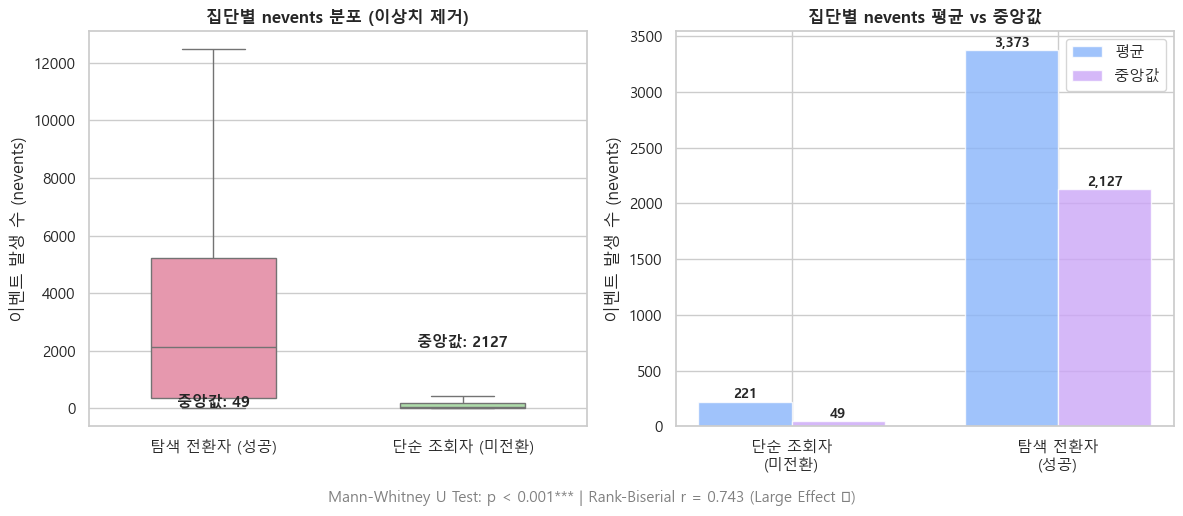

In [224]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = df[df['viewed'] == 1].copy()
plot_df['explored_label'] = plot_df['explored'].map({
    0: '단순 조회자 (미전환)',
    1: '탐색 전환자 (성공)'
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 박스플롯
import seaborn as sns
sns.boxplot(
    data=plot_df, x='explored_label', y='nevents',
    palette=['#f38ba8', '#a6e3a1'],
    showfliers=False, width=0.5, ax=axes[0]
)
medians = plot_df.groupby('explored_label')['nevents'].median()
for i, (label, val) in enumerate(medians.items()):
    axes[0].text(i, val + 10, f'중앙값: {val:.0f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('집단별 nevents 분포 (이상치 제거)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('이벤트 발생 수 (nevents)')

# 2. 평균 vs 중앙값 비교 막대
x = np.arange(2)
width = 0.35
labels = ['단순 조회자\n(미전환)', '탐색 전환자\n(성공)']
means = [221.1, 3372.8]
medians_val = [49, 2127]

axes[1].bar(x - width/2, means, width, label='평균', color='#89b4fa', alpha=0.8)
axes[1].bar(x + width/2, medians_val, width, label='중앙값', color='#cba6f7', alpha=0.8)

for i, (m, md) in enumerate(zip(means, medians_val)):
    axes[1].text(i - width/2, m + 30, f'{m:,.0f}', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(i + width/2, md + 30, f'{md:,.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('집단별 nevents 평균 vs 중앙값', fontweight='bold')
axes[1].set_ylabel('이벤트 발생 수 (nevents)')
axes[1].legend()

# p-value 및 효과크기 표기
fig.text(0.5, -0.02,
         'Mann-Whitney U Test: p < 0.001*** | Rank-Biserial r = 0.743 (Large Effect 🔥)',
         ha='center', fontsize=11, color='gray')

plt.tight_layout()
plt.show()


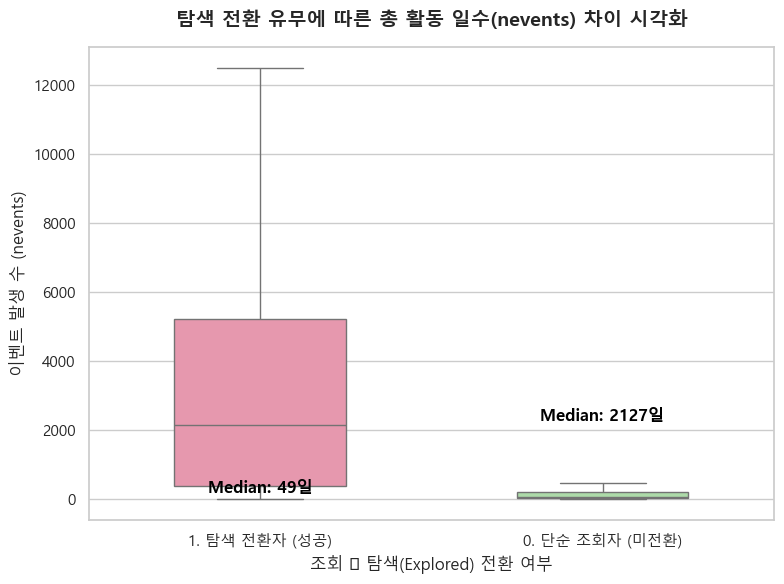

In [300]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화를 위한 데이터 준비 (viewed == 1 인원만)
plot_df = df[df['viewed'] == 1].copy()

# 보기 좋게 라벨 달기
plot_df['explored_label'] = plot_df['explored'].map({
    0: '0. 단순 조회자 (미전환)', 
    1: '1. 탐색 전환자 (성공)'
})

fig, ax = plt.subplots(figsize=(8, 6))

# 2. 박스 플롯 시각화 (이상치 제거로 찌그러짐 방지)
sns.boxplot(
    data=plot_df, 
    x='explored_label', 
    y='nevents', 
    palette=['#f38ba8', '#a6e3a1'],  # 붉은색(실패) vs 녹색(성공)
    showfliers=False,                # 극단적인 출석왕(이상치) 점들을 지워줌
    width=0.5,
    ax=ax
)

# 3. 비모수 검정의 핵심인 '중앙값(Median)'을 차트 위에 숫자로 찍어주기
medians = plot_df.groupby('explored_label')['nevents'].median()
for i, median_val in enumerate(medians):
    ax.text(
        i, median_val + 0.3,             # 박스 중앙값 선에서 살짝 위에 표기
        f'Median: {median_val:.0f}일', 
        ha='center', va='bottom', 
        fontweight='bold', color='black', fontsize=12
    )

# 4. 축과 타이틀 디자인 설정
ax.set_title('탐색 전환 유무에 따른 총 활동 일수(nevents) 차이 시각화', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('조회 👉 탐색(Explored) 전환 여부', fontsize=12)
ax.set_ylabel('이벤트 발생 수 (nevents)', fontsize=12)

plt.tight_layout()
plt.show()


전환율 상위 20%, 하위 20% 비교

In [226]:
import pandas as pd
import numpy as np

# 1. 코스별 '조회 -> 탐색' 전환율 계산 
course_stats = df[df['viewed'] == 1].groupby('course_id').agg(
    total_viewers=('viewed', 'size'),
    explore_rate=('explored', 'mean')
)
course_stats['explore_rate'] *= 100

# 2. 분석의 신뢰성을 위해 조회자가 너무 적은 아웃라이어 코스(예: 100명 미만) 제외 처리
course_stats = course_stats[course_stats['total_viewers'] > 100]

# 3. 텍스트 분할 (Parsing)을 통해 [대학/기관], [과목분야], [개설시기] 도출 
# 예: HarvardX/CS50x/2012  ->  대학: HarvardX, 과목: CS50x, 시기: 2012
course_stats['institution'] = course_stats.index.str.split('/').str[0]
course_stats['subject'] = course_stats.index.str.split('/').str[1]
course_stats['term'] = course_stats.index.str.split('/').str[2]

# 4. 각 코스별 등록 학습자들의 '평균적인 스펙' 가져와 합치기
user_traits = df[df['viewed'] == 1].groupby('course_id').agg(
    avg_age=('age', 'mean'),                      # 코스별 평균 연령
    avg_forum_posts=('nforum_posts', 'mean'),     # 코스별 평균 게시판 활동량
    avg_ndays_act=('ndays_act', 'mean'),          # 코스별 평균 활동 일수
    avg_nchapters=('nchapters', 'mean')           # 코스별 평균 챕터 도달 수
)
course_full_stats = course_stats.join(user_traits)

# 5. 전환율 최상위 20% 그룹 (Top) vs 최하위 20% 그룹 (Bottom) 라벨링
top_20_cutoff = course_full_stats['explore_rate'].quantile(0.8)
bottom_20_cutoff = course_full_stats['explore_rate'].quantile(0.2)

course_full_stats['tier'] = '2. Middle (보통)'
course_full_stats.loc[course_full_stats['explore_rate'] >= top_20_cutoff, 'tier'] = '1. Top 20% (우수)'
course_full_stats.loc[course_full_stats['explore_rate'] <= bottom_20_cutoff, 'tier'] = '3. Bottom 20% (부진)'

# --- 💡 인사이트 도출 결과 출력 ---

print("■ 인사이트 1. 상위 20% 우수 코스와 하위 20% 부진 코스의 핵심 스펙 차이 ■")
display(course_full_stats[course_full_stats['tier'] != '2. Middle (보통)']
        .groupby('tier')[['explore_rate', 'avg_age', 'avg_forum_posts', 'avg_ndays_act', 'avg_nchapters']]
        .mean().round(2))

print("\n■ 인사이트 2. 기관(하버드 vs MIT 등)에 따른 시그니처 전환율 파워 ■")
display(course_full_stats.groupby('institution')[['total_viewers', 'explore_rate']].mean().round(1))

# (만약 보고 싶으시다면) 하위 20% 코스의 시기(term)이나 분야(subject)가 한 쪽으로 쏠려있는지도 확인 가능합니다.
# course_full_stats[course_full_stats['tier'] == '3. Bottom 20% (부진)']['term'].value_counts()


■ 인사이트 1. 상위 20% 우수 코스와 하위 20% 부진 코스의 핵심 스펙 차이 ■


,explore_rate,avg_age,avg_forum_posts,avg_ndays_act,avg_nchapters
tier,,,,,
1. Top 20% (우수),18.1700,27.2200,0.0200,7.9300,3.7400
3. Bottom 20% (부진),4.3400,26.3700,0.0100,5.7600,3.8800



■ 인사이트 2. 기관(하버드 vs MIT 등)에 따른 시그니처 전환율 파워 ■


,total_viewers,explore_rate
institution,,
HarvardX,25785.6000,12.4000
MITx,17857.5000,10.1000


In [232]:
import pandas as pd
import numpy as np

# 1. 인구통계학적 텍스트 데이터를 비율(%) 계산용 수치형(0과 1) 지표로 변환
viewed_df = df[df['viewed'] == 1].copy()

# 성별
viewed_df['is_male'] = (viewed_df['gender'] == 'm').astype(int)
viewed_df['is_female'] = (viewed_df['gender'] == 'f').astype(int)

# 고학력자 (학부, 석사, 박사 이상 보유자) 비율
high_edu = ["Bachelor's", "Master's", "Doctorate"]
viewed_df['is_high_edu'] = viewed_df['LoE_DI'].isin(high_edu).astype(int)

# 대표 국가 (미국 수강생) 비율
viewed_df['is_us'] = (viewed_df['final_cc_cname_DI'] == 'United States').astype(int)

# 2. 코스(course_id) 별로 인구통계 및 행동지표 평균(비율) 집계
course_full = viewed_df.groupby('course_id').agg(
    # [퍼널 전환율 메인 지표]
    total_viewers=('viewed', 'size'),
    explore_rate=('explored', 'mean'), # 1의 평균이 곧 % 값이 됨
    
    # ■ 1. 인구 통계 지표 (Demographics) ■
    avg_age=('age', 'mean'),               # 코스별 평균 나이
    pct_male=('is_male', 'mean'),          # 남성 수강생 비율
    pct_female=('is_female', 'mean'),      # 여성 수강생 비율
    pct_high_edu=('is_high_edu', 'mean'),  # 대졸 이상 학력자 비율
    pct_us=('is_us', 'mean'),              # 미국 국적 수강생 비율
    
    # ■ 2. 행동 지표 (Behaviors) ■
    avg_nevents=('nevents', 'mean'),       # 코스별 총 클릭/상호작용 횟수
    avg_ndays_act=('ndays_act', 'mean'),   # 출석 활동 일수
    avg_nchapters=('nchapters', 'mean'),   # 도달 확인 챕터 수
    avg_nforum=('nforum_posts', 'mean')    # 게시판(질의응답) 글 작성 수
)

# 3. 사람 눈에 보기 좋게 퍼센트 단위 변환 (x100)
percent_cols = ['explore_rate', 'pct_male', 'pct_female', 'pct_high_edu', 'pct_us']
course_full[percent_cols] *= 100

# 모수가 100명 미만인 노이즈성 코스 제거 
course_full = course_full[course_full['total_viewers'] > 100]

# 4. '조회->탐색' 비율 기준 상위 20%(성공 코스) vs 하위 20%(부진 코스) 분류
top_20 = course_full['explore_rate'].quantile(0.8)
bottom_20 = course_full['explore_rate'].quantile(0.2)

course_full['tier'] = '2. Middle (보통)'
course_full.loc[course_full['explore_rate'] >= top_20, 'tier'] = '1. Top 20% (전환 우수)'
course_full.loc[course_full['explore_rate'] <= bottom_20, 'tier'] = '3. Bottom 20% (전환 부진)'

# 5. 티어별 인구/행동 통계 비교 출력 (T를 사용해 테이블을 눕혀서 비교하기 쉽게 출력)
tier_comparison = course_full[course_full['tier'] != '2. Middle (보통)'].groupby('tier').mean().round(2)

print("🏆 우수 과목(상위 20%) vs 🚨 부진 과목(하위 20%) 수강생 스펙 종합 비교\n")

# 조회자 수(total_viewers)를 포함하여 총 11개 컬럼을 보기 좋게 순서 정렬
col_order = ['explore_rate', 'total_viewers',
             'avg_age', 'pct_male', 'pct_female', 'pct_high_edu', 'pct_us', 
             'avg_ndays_act', 'avg_nevents', 'avg_nchapters', 'avg_nforum']

# 순서에 맞게 데이터프레임 재배열
tier_comparison = tier_comparison[col_order]

# 11개 컬럼명 가시성 확보용 변환
tier_comparison.columns = [
    '조회->탐색 전환율 (%)', '코스당 평균 수강생(조회자) 수',
    '평균 연령 (Age)', '남성 수강 비율 (%)', '여성 수강 비율 (%)', '대졸 이상 학력자 비율 (%)', '미국 거주자 비율 (%)',
    '평균 활동 출석일수 (ndays)', '총 상호작용 클릭 횟수 (nevents)', '진행 확인 챕터 수 (nchapters)', '포럼 활동량 (posts)'
]

# 한눈에 비교하기 쉽게 표를 눕혀서(Transpose) 출력
display(tier_comparison.T)



🏆 우수 과목(상위 20%) vs 🚨 부진 과목(하위 20%) 수강생 스펙 종합 비교



tier,1. Top 20% (전환 우수),3. Bottom 20% (전환 부진)
조회->탐색 전환율 (%),18.1700,4.3400
코스당 평균 수강생(조회자) 수,21293.5000,19034.5000
평균 연령 (Age),27.2200,26.3700
남성 수강 비율 (%),61.4700,62.8800
여성 수강 비율 (%),24.8900,18.3700
대졸 이상 학력자 비율 (%),61.7700,45.5400
미국 거주자 비율 (%),29.3700,36.2900
평균 활동 출석일수 (ndays),7.9300,5.7600
총 상호작용 클릭 횟수 (nevents),676.1600,451.9000
진행 확인 챕터 수 (nchapters),3.7400,3.8800


In [233]:
from scipy import stats
import pandas as pd

# 1. 대상 그룹 확보 (Top 20% 과목들 vs Bottom 20% 과목들)
top_group = course_full[course_full['tier'] == '1. Top 20% (전환 우수)']
bottom_group = course_full[course_full['tier'] == '3. Bottom 20% (전환 부진)']

# 2. 통계 검정을 진행할 타겟 컬럼 리스트 지정
test_columns = [
    'avg_age', 'pct_male', 'pct_female', 'pct_us', 
    'avg_ndays_act', 'avg_nevents', 'avg_nchapters', 'avg_nforum', 'total_viewers'
]

# 3. 돌려볼 결과값을 담을 리스트 세팅
results = []

for col in test_columns:
    # 각 지표별로 결측치 제거 후 추출
    top_vals = top_group[col].dropna()
    bottom_vals = bottom_group[col].dropna()
    
    # 두 집단의 평균값 단순 산출
    top_mean = top_vals.mean()
    bottom_mean = bottom_vals.mean()
    
    # 비모수 통계 검정 (과목 간의 평균 차이가 우연인지 진짜인지 검증)
    stat, p_val = stats.mannwhitneyu(top_vals, bottom_vals, alternative='two-sided')
    
    # P-value 0.05 를 기준으로 유의미 판단
    is_significant = "⭐ 유의미(O)" if p_val < 0.05 else "무의미(X)"
    
    # 유의미한 경우 어느 쪽이 더 높은지 화살표 방향으로 표시
    if p_val < 0.05:
        trend = "Top 코스가 높음 🔺" if top_mean > bottom_mean else "Bottom 코스가 높음 🔻"
    else:
        trend = "통계적 차이 없음 -"
        
    results.append({
        '검정 대상 지표 (컬럼명)': col,
        'Top 20% 평균': round(top_mean, 2),
        'Bottom 20% 평균': round(bottom_mean, 2),
        'P-value': f"{p_val:.5f}",
        '통계적 유의성': is_significant,
        '결론 (방향성)': trend
    })

# 4. 보기 좋게 데이터프레임 구조로 한 번에 출력
test_result_df = pd.DataFrame(results)
display(test_result_df)


,검정 대상 지표 (컬럼명),Top 20% 평균,Bottom 20% 평균,P-value,통계적 유의성,결론 (방향성)
0,avg_age,27.2200,26.3700,0.48571,무의미(X),통계적 차이 없음 -
1,pct_male,61.4700,62.8800,0.88571,무의미(X),통계적 차이 없음 -
2,pct_female,24.8900,18.3700,0.68571,무의미(X),통계적 차이 없음 -
3,pct_us,29.3700,36.2900,0.34286,무의미(X),통계적 차이 없음 -
4,avg_ndays_act,7.9300,5.7600,0.34286,무의미(X),통계적 차이 없음 -
5,avg_nevents,676.1600,451.9000,0.34286,무의미(X),통계적 차이 없음 -
6,avg_nchapters,3.7400,3.8800,0.68571,무의미(X),통계적 차이 없음 -
7,avg_nforum,0.0200,0.0100,0.68571,무의미(X),통계적 차이 없음 -
8,total_viewers,21293.5000,19034.5000,1.00000,무의미(X),통계적 차이 없음 -


- 표본 자체를 과목 수로 줄여버리니 역시 유의성이 떨어진 모습

- top 20, bottom 20 -> 각각의 학생 수 전체로 표본 확장(코스 평균 X)

In [234]:
from scipy import stats
import pandas as pd

# 1. 아까 계산해 둔 과목별 등급표(Top/Bottom)를 딕셔너리로 저장
tier_dict = course_full['tier'].to_dict()

# 2. 조회(viewed==1) 한 사람 모수 60만 명 원본 데이터 복사
student_full_df = df[df['viewed'] == 1].copy()

# 3. 핵심 마법 🌟: 각 학생이 들은 course_id에 맞춰 (1.Top 20 / 2.Middle / 3.Bottom) 라벨표 점지해주기
student_full_df['course_tier'] = student_full_df['course_id'].map(tier_dict)

# 4. Top 20% 강의를 들은 '학생들' vs Bottom 20% 강의를 들은 '학생들' 분리
top_students = student_full_df[student_full_df['course_tier'] == '1. Top 20% (전환 우수)']
bottom_students = student_full_df[student_full_df['course_tier'] == '3. Bottom 20% (전환 부진)']

print(f"👥 [표본 크기 복원 완료]")
print(f"Top 20% 코스 수강생(N): {len(top_students):,}명")
print(f"Bottom 20% 코스 수강생(N): {len(bottom_students):,}명\n")

# 5. 개별 학생 행동 지표 5가지 통계 검정 다시 진행 (Mann-Whitney U Test)
test_columns = ['age', 'ndays_act', 'nevents', 'nchapters', 'nplay_video','nforum_posts']
results = []

for col in test_columns:
    top_vals = top_students[col].dropna()
    bottom_vals = bottom_students[col].dropna()
    
    top_mean = top_vals.mean()
    bottom_mean = bottom_vals.mean()
    
    # N이 수만 명이 되었으므로 통계 검정이 아주 정밀하고 강력하게 동작합니다!
    stat, p_val = stats.mannwhitneyu(top_vals, bottom_vals, alternative='two-sided')
    
    is_significant = "⭐ 유의미(O)" if p_val < 0.05 else "무의미(X)"
    trend = "Top 학생이 강함 🔺" if top_mean > bottom_mean else "Bottom 학생이 강함 🔻"
    
    results.append({
        '개별 학생 지표 (컬럼명)': col,
        'Top 코스 학생 평균': round(top_mean, 2),
        'Bottom 코스 학생 평균': round(bottom_mean, 2),
        'P-value': f"{p_val:.5e}",
        '유의성 (p<0.05)': is_significant,
        '결론 (방향성)': trend
    })

# 6. 결과 출력
display(pd.DataFrame(results))


👥 [표본 크기 복원 완료]
Top 20% 코스 수강생(N): 85,174명
Bottom 20% 코스 수강생(N): 76,138명



,개별 학생 지표 (컬럼명),Top 코스 학생 평균,Bottom 코스 학생 평균,P-value,유의성 (p<0.05),결론 (방향성)
0,age,27.8800,27.1200,1.10452e-241,⭐ 유의미(O),Top 학생이 강함 🔺
1,ndays_act,7.0000,6.1200,4.40047e-180,⭐ 유의미(O),Top 학생이 강함 🔺
2,nevents,512.2500,466.0900,9.53964e-01,무의미(X),Top 학생이 강함 🔺
3,nchapters,3.8600,3.6800,2.90158e-24,⭐ 유의미(O),Top 학생이 강함 🔺
4,nplay_video,165.7900,74.1100,7.19568e-123,⭐ 유의미(O),Top 학생이 강함 🔺
5,nforum_posts,0.0100,0.0200,2.71176e-06,⭐ 유의미(O),Bottom 학생이 강함 🔻


In [236]:
import numpy as np
from scipy import stats
import pandas as pd

# (1~4번 그룹 데이터 분리 코드는 기존과 완벽히 동일합니다.)

# 5. 통계 검정 및 '효과 크기(Effect Size)' 동시 계산
test_columns = ['age', 'ndays_act', 'nevents', 'nchapters','nplay_video', 'nforum_posts']
results = []

for col in test_columns:
    top_vals = top_students[col].dropna()
    bottom_vals = bottom_students[col].dropna()
    
    n1 = len(top_vals)
    n2 = len(bottom_vals)
    
    # 단순 평균
    top_mean = top_vals.mean()
    bottom_mean = bottom_vals.mean()
    
    # Mann-Whitney U Test (통계적 유의성 검증)
    stat, p_val = stats.mannwhitneyu(top_vals, bottom_vals, alternative='two-sided')
    
    # --- 🌟 핵심: Cohen's d (효과 크기) 계산 로직 ---
    # 두 집단의 데이터 분산 폭을 합친 통합 표준편차(Pooled Std) 산출
    s_pooled = np.sqrt(((n1 - 1) * top_vals.std()**2 + (n2 - 1) * bottom_vals.std()**2) / (n1 + n2 - 2))
    
    # (Top 평균 - Bottom 평균)을 표준표차로 나누어 스케일 표준화
    cohens_d = (top_mean - bottom_mean) / s_pooled
    
    # 효과 크기 실무적 치환 (Cohen의 통상적 가이드라인: 0.2=Small, 0.5=Medium, 0.8=Large)
    abs_d = abs(cohens_d)
    if abs_d >= 0.8:
        effect_desc = "매우 큼 (Large) 🔥"
    elif abs_d >= 0.5:
        effect_desc = "중간 (Medium) 🔸"
    elif abs_d >= 0.2:
        effect_desc = "작음 (Small) 🔹"
    else:
        effect_desc = "차이 체감불가 (Trivial) 💧"

    # 승패 방향
    trend = "Top 학생층 강세 🔺" if top_mean > bottom_mean else "Bottom 학생층 강세 🔻"
    
    results.append({
        '개별 학생 지표': col,
        'Top 코스 수강생': f"{top_mean:.1f}",
        'Bottom 코스 수강생': f"{bottom_mean:.1f}",
        'P-value': f"{p_val:.5e}",
        "효과 크기 (Cohen's d)": f"{cohens_d:.3f}",
        '실무적 차이 체감': effect_desc,
        '전체 결론': trend
    })

# 6. 보기 좋게 데이터프레임으로 출력
effect_size_df = pd.DataFrame(results)
display(effect_size_df)


,개별 학생 지표,Top 코스 수강생,Bottom 코스 수강생,P-value,효과 크기 (Cohen's d),실무적 차이 체감,전체 결론
0,age,27.9,27.1,1.10452e-241,0.086,차이 체감불가 (Trivial) 💧,Top 학생층 강세 🔺
1,ndays_act,7.0,6.1,4.40047e-180,0.074,차이 체감불가 (Trivial) 💧,Top 학생층 강세 🔺
2,nevents,512.2,466.1,9.53964e-01,0.030,차이 체감불가 (Trivial) 💧,Top 학생층 강세 🔺
3,nchapters,3.9,3.7,2.90158e-24,0.043,차이 체감불가 (Trivial) 💧,Top 학생층 강세 🔺
4,nplay_video,165.8,74.1,7.19568e-123,0.235,작음 (Small) 🔹,Top 학생층 강세 🔺
5,nforum_posts,0.0,0.0,2.71176e-06,-0.037,차이 체감불가 (Trivial) 💧,Bottom 학생층 강세 🔻


In [208]:
from scipy.stats import chi2_contingency

print("■ 인구통계(범주형) 데이터 카이제곱 통계 검정 ■\n")

# 1. 성별(gender) 비율 차이 검정
gender_crosstab = pd.crosstab(student_full_df['course_tier'], student_full_df['gender'])
chi2, p_val, _, _ = chi2_contingency(gender_crosstab.loc[['1. Top 20% (전환 우수)', '3. Bottom 20% (전환 부진)']])

print(f"1. 성별(Gender) 구성비율 차이 p-value: {p_val:.5e}")
if p_val < 0.05:
    print(" 👉 [결론] Top 코스와 Bottom 코스를 듣는 학생들의 남녀 성비 쏠림이 유의미하게 다릅니다!\n")

# 2. 고학력자(is_high_edu) 비율 차이 검정 (이전 코드에서 is_high_edu 0/1 매핑이 되어있을 때)
# (만약 에러가 난다면 위 크로스탭 방식처럼 원본 LoE_DI 컬럼을 활용하시면 됩니다.)
if 'is_high_edu' in student_full_df.columns:
    edu_crosstab = pd.crosstab(student_full_df['course_tier'], student_full_df['is_high_edu'])
    chi2_edu, p_val_edu, _, _ = chi2_contingency(edu_crosstab.loc[['1. Top 20% (전환 우수)', '3. Bottom 20% (전환 부진)']])
    print(f"2. 대졸자 이상 비율 차이 p-value: {p_val_edu:.5e}")


■ 인구통계(범주형) 데이터 카이제곱 통계 검정 ■

1. 성별(Gender) 구성비율 차이 p-value: 0.00000e+00
 👉 [결론] Top 코스와 Bottom 코스를 듣는 학생들의 남녀 성비 쏠림이 유의미하게 다릅니다!



# KPI: reg -> view 전환율

In [301]:
# 1. 타겟 누수 점검: 원본 df 그대로 사용 (데이터 수집 시스템 자체의 문제 여부 확인)
# ✅ 분석 전용 데이터프레임 생성: gender == 'o' 행 제외 (원본 df는 보존)
df_analysis = df[df['gender'] != 'o'].copy()

check_df = df.copy()
check_df['is_missing_profile'] = check_df[['age', 'gender', 'LoE_DI', 'final_cc_cname_DI']].isnull().any(axis=1)

leakage_check = check_df.groupby('viewed')['is_missing_profile'].mean() * 100
print("[1. 타겟 누수(Target Leakage) 의혹 점검]")
print(f"- View=1 (조회 성공) 집단의 프로필 누락 비율: {leakage_check[1]:.1f}%")
print(f"- View=0 (조회 실패) 집단의 프로필 누락 비율: {leakage_check[0]:.1f}%")

if abs(leakage_check[1] - leakage_check[0]) > 30:
    print(" 🚨 비상! 두 집단 간 결측률 차이가 비정상적으로 큽니다.")
else:
    print(" ✅ 정상! 결측률이 비슷비슷합니다. 타겟 누수 걱정은 접어두셔도 좋습니다.\n")


# 2. 생존자 편향 점검: df_analysis 기준으로 변경 (실제 분석 모수와 동일하게 맞춤)
# df_analysis 기반 베이스라인 재산출
analysis_total = len(df_analysis)
analysis_viewed = df_analysis['viewed'].sum()
analysis_base_rate = analysis_viewed / analysis_total * 100

# dropna 후 생존 집단의 전환율 산출
alive_df = df_analysis[['viewed', 'age', 'gender', 'LoE_DI', 'final_cc_cname_DI']].dropna()
alive_view_rate = alive_df['viewed'].mean() * 100

print("[2. 생존자 편향(Selection Bias) 의혹 점검]")
print(f"- df_analysis 전체 베이스라인 View 전환율: {analysis_base_rate:.2f}%")
print(f"- dropna 후 생존 집단의 View 전환율: {alive_view_rate:.2f}%")

if abs(analysis_base_rate - alive_view_rate) > 5:
    print(" 🚨 비상! 회귀분석 해석 시 생존자 편향에 주의가 필요합니다.")
else:
    print(" ✅ 정상! 결측치가 무작위로 분포(MCAR)하여 분석 신뢰도에 문제가 없습니다.")


[1. 타겟 누수(Target Leakage) 의혹 점검]
- View=1 (조회 성공) 집단의 프로필 누락 비율: 17.2%
- View=0 (조회 실패) 집단의 프로필 누락 비율: 12.1%
 ✅ 정상! 결측률이 비슷비슷합니다. 타겟 누수 걱정은 접어두셔도 좋습니다.

[2. 생존자 편향(Selection Bias) 의혹 점검]
- df_analysis 전체 베이스라인 View 전환율: 60.93%
- dropna 후 생존 집단의 View 전환율: 59.51%
 ✅ 정상! 결측치가 무작위로 분포(MCAR)하여 분석 신뢰도에 문제가 없습니다.


In [303]:
print(f"[전처리] gender='o' 제외 후 분석 대상: {len(df_analysis):,}명 (제외된 행: {len(df) - len(df_analysis):,}명)\n")

print("■ 카이제곱 검정 '기대 빈도(Expected Frequency) 5 이상' 필수 조건 팩트체크 ■\n")

cat_vars = ['gender', 'LoE_DI', 'age_group', 'final_cc_cname_DI'] 

for var in cat_vars:
    # 1. df_analysis 기준으로 결측치 임시 제거 후 원본 교차표 생성
    temp_df = df_analysis[[var, 'viewed']].dropna()
    crosstab = pd.crosstab(temp_df[var], temp_df['viewed'])
    
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    
    print(f"[{var} 집단의 관측 전제조건(기대 빈도) 검사]")
    
    expected_df = pd.DataFrame(
        expected, 
        index=crosstab.index, 
        columns=['View=0 (기대 인원)', 'View=1 (기대 인원)']
    ).round(1)
    
    display(expected_df)
    
    invalid_cells = (expected < 5).sum()
    total_cells = expected.size
    
    print(f"👉 전체 {total_cells}개의 칸(Cell) 중, '5명 미만'인 칸 개수: {invalid_cells}개")
    
    if invalid_cells > 0:
        print(f"🚨 [경고] {var} 검정 무효! 기대 빈도가 부족하여 Fisher's Exact Test로 대체해야 합니다.\n")
    else:
        print(f"✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!\n")
        
    print("-" * 65 + "\n")


[전처리] gender='o' 제외 후 분석 대상: 533,985명 (제외된 행: 8명)

■ 카이제곱 검정 '기대 빈도(Expected Frequency) 5 이상' 필수 조건 팩트체크 ■

[gender 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
gender,,
f,47201.7000,73611.3000
m,132958.8000,207350.2000
unknown,28467.6000,44395.4000


👉 전체 6개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[LoE_DI 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
LoE_DI,,
Bachelor's,71665.7000,111763.3000
Doctorate,4555.2000,7103.8000
Less than Secondary,4363.7000,6805.3000
Master's,39286.5000,61267.5000
Secondary,54432.7000,84888.3000
unknown,34324.2000,53528.8000


👉 전체 12개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[age_group 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
age_group,,
20s,105324.9000,164255.1000
30s,33706.1000,52564.9000
40s,9947.6000,15513.4000
50s,4227.0000,6592.0000
60_plus,1839.8000,2869.2000
under_20,21917.1000,34179.9000
unknown,31665.5000,49382.5000


👉 전체 14개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[final_cc_cname_DI 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
final_cc_cname_DI,,
Australia,2141.4000,3339.6000
Bangladesh,1023.2000,1595.8000
Brazil,6242.6000,9735.4000
Canada,4143.4000,6461.6000
China,1859.7000,2900.3000
Colombia,1670.6000,2605.4000
Egypt,3219.8000,5021.2000
France,1581.9000,2467.1000
Germany,2822.0000,4401.0000


👉 전체 68개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------



In [212]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint

# ※ df_analysis는 이전 셀에서 gender='o' 제외하여 이미 정의된 상태

# =========================================================
# [1단계] 전체 전환율 베이스라인 및 95% 신뢰구간(CI) 확인
# =========================================================
print("■ [1단계] 기초 체력 확인 (Baseline & 95% CI) ■")
total_users = len(df_analysis)
viewed_users = df_analysis['viewed'].sum()
overall_rate = viewed_users / total_users

ci_low, ci_upp = proportion_confint(count=viewed_users, nobs=total_users, alpha=0.05, method='normal')

print(f"- 분석 대상 가입자(gender='o' 제외): {total_users:,}명 | 실제 강의 열람: {viewed_users:,}명")
print(f"- 평균 '가입 ➔ 조회' 전환율: {overall_rate * 100:.2f}%")
print(f"- 95% 신뢰구간(CI): {ci_low * 100:.2f}% ~ {ci_upp * 100:.2f}%\n")
print("-" * 65 + "\n")


# =========================================================
# [2단계] 카이제곱(Chi-square): 그룹별 단순 전환율 차이 존재 여부
# =========================================================
print("■ [2단계] 후보 변수 예선전 (카이제곱 검정: P-value 확인) ■")
cat_vars = ['gender', 'LoE_DI', 'age_group', 'final_cc_cname_DI']
chi2_results = {}

for var in cat_vars:
    temp_df = df_analysis[[var, 'viewed']].dropna()
    crosstab = pd.crosstab(temp_df[var], temp_df['viewed'])

    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    chi2_results[var] = {'chi2': chi2, 'p_val': p_val, 'crosstab': crosstab}

    print(f"- [{var}] 집단 간 전환율 차이 유의성(P-value): {p_val:.5e}")
print("-" * 65 + "\n")


# =========================================================
# [3단계] 로지스틱 회귀: 어떤 변수가 '독립적'으로 유의한지 본선 검증
# =========================================================
print("■ [3단계] 진짜 원인 색출 (로지스틱 회귀: 독립적 P-value 확인) ■")
model_df = df_analysis[['viewed', 'age', 'gender', 'LoE_DI']].dropna().copy()
model_df['is_male'] = (model_df['gender'] == 'm').astype(int)
model_df['is_high_edu'] = model_df['LoE_DI'].isin(["Bachelor's", "Master's", "Doctorate"]).astype(int)

Y = model_df['viewed']
X = model_df[['age', 'is_male', 'is_high_edu']]
X = sm.add_constant(X)

logit_model = sm.Logit(Y, X).fit(disp=False)

print(f"- 유사 결정계수(Pseudo R-squ): {logit_model.prsquared:.4f}")
print("- 각 변수별 독립적 유의성 (다른 변수를 고정했을 때도 유의미한가?):")
for var, p_val in logit_model.pvalues.items():
    if var == 'const': continue
    print(f"  * {var} 의 P-value = {p_val:.5e}")
print("-" * 65 + "\n")


# =========================================================
# [4단계] 효과 크기 보고: 비즈니스적으로 '쓸모'가 있는가?
# =========================================================
print("■ [4단계] 비즈니스 임팩트 판단 (실질적 효과 크기 산출) ■")

print("\n1) 범주형 변수의 차이 규모 (Cramer's V 기준)")
for var, res in chi2_results.items():
    n = res['crosstab'].sum().sum()
    min_dim = min(res['crosstab'].shape) - 1
    cramers_v = np.sqrt(res['chi2'] / (n * min_dim))

    if cramers_v >= 0.5: effect = "매우 큼 🔥"
    elif cramers_v >= 0.3: effect = "중간 🔸"
    elif cramers_v >= 0.1: effect = "약함 🔹"
    else: effect = "미미함 💧 (통계적으로는 차이나지만 실무 임팩트 없음)"

    print(f"  - [{var}] Cramer's V: {cramers_v:.3f} 👉 실무적 체감 규모: {effect}")

print("\n2) 다중 변수의 순수 타격량 (Odds Ratio 기준)")
odds_ratios = np.exp(logit_model.params)
for var, or_val in odds_ratios.items():
    if var == 'const': continue
    print(f"  - [{var}] Odds Ratio: {or_val:.3f}배 👉 (1.0에 가까울수록 현실 타격감 없음)")


■ [1단계] 기초 체력 확인 (Baseline & 95% CI) ■
- 분석 대상 가입자(gender='o' 제외): 533,985명 | 실제 강의 열람: 325,357명
- 평균 '가입 ➔ 조회' 전환율: 60.93%
- 95% 신뢰구간(CI): 60.80% ~ 61.06%

-----------------------------------------------------------------

■ [2단계] 후보 변수 예선전 (카이제곱 검정: P-value 확인) ■
- [gender] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
- [LoE_DI] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
- [age_group] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
- [final_cc_cname_DI] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
-----------------------------------------------------------------

■ [3단계] 진짜 원인 색출 (로지스틱 회귀: 독립적 P-value 확인) ■
- 유사 결정계수(Pseudo R-squ): 0.0018
- 각 변수별 독립적 유의성 (다른 변수를 고정했을 때도 유의미한가?):
  * age 의 P-value = 1.16278e-11
  * is_male 의 P-value = 3.48991e-201
  * is_high_edu 의 P-value = 1.36965e-09
-----------------------------------------------------------------

■ [4단계] 비즈니스 임팩트 판단 (실질적 효과 크기 산출) ■

1) 범주형 변수의 차이 규모 (Cramer's V 기준)
  - [gender] Cramer's V: 0.082 👉 실무적 체감 규모: 미미함 💧 (통계적으로는 차이나지만 실무 임팩트 없음)
  - [LoE_DI] Cram

In [201]:
# 1. 로지스틱 회귀에 사용될 원본 컬럼들만 떼어온 크기
original_count = len(df[['viewed', 'age', 'gender', 'LoE_DI','final_cc_cname_DI']])

# 2. 결측치가 단 하나라도 포함되어 삭제(dropna)된 후 살아남은 크기
cleaned_count = len(df[['viewed', 'age', 'gender', 'LoE_DI','final_cc_cname_DI']].dropna())

# 3. 날아간 횟수와 비율 계산
dropped_count = original_count - cleaned_count
dropped_ratio = (dropped_count / original_count) * 100

print("■ [데이터 누수(Data Loss) 점검] ■")
print(f"- 회귀분석 투입 전 원본 모수: {original_count:,}건")
print(f"- 결측치 제거 후 생존 모수: {cleaned_count:,}건")
print(f"🚨 최종적으로 모델에서 삭제된(dropna) 데이터: {dropped_count:,}건 (전체의 {dropped_ratio:.2f}% 삭제됨)")


■ [데이터 누수(Data Loss) 점검] ■
- 회귀분석 투입 전 원본 모수: 533,993건
- 결측치 제거 후 생존 모수: 452,939건
🚨 최종적으로 모델에서 삭제된(dropna) 데이터: 81,054건 (전체의 15.18% 삭제됨)


In [202]:
import pandas as pd

print("■ 🌍 국가별 '가입 ➔ 조회(열람)' 전환율 랭킹 ■\n")

# 1. 국가(final_cc_cname_DI) 단위로 총 가입자 및 실제 조회자 집계
country_stats = df.groupby('final_cc_cname_DI')['viewed'].agg(
    total_registered='size',   # 전체 가입자 수 (모수)
    total_viewed='sum'         # 실제 조회(1)를 한 사람 수
)

# 2. 직관적인 퍼센트(%) 전환율 계산
country_stats['view_rate(%)'] = (country_stats['total_viewed'] / country_stats['total_registered']) * 100

# 3. 통계적 노이즈 제거: 가입자가 1,000명 미만인 국가는 순위권에서 제외 (필수)
country_stats = country_stats[country_stats['total_registered'] >= 1000]

# 4. 전환율이 높은 국가부터 내림차순 정렬
country_stats = country_stats.sort_values(by='view_rate(%)', ascending=False)

# 5. 보기 좋게 출력
display(country_stats.round(1))


■ 🌍 국가별 '가입 ➔ 조회(열람)' 전환율 랭킹 ■



,total_registered,total_viewed,view_rate(%)
final_cc_cname_DI,,,
Poland,4697,3919,83.4000
Spain,8741,6628,75.8000
Germany,7223,5398,74.7000
Japan,2126,1581,74.4000
Greece,4464,3284,73.6000
Other Europe,35434,26021,73.4000
Mexico,4946,3585,72.5000
Ukraine,3487,2514,72.1000
Colombia,4276,3055,71.4000


In [213]:
from scipy import stats
import pandas as pd
import numpy as np

# 1. Unknown/Other 포함 vs 제외 비교
print("■ Unknown/Other 제외 여부에 따른 Cramer's V 비교 ■\n")

for label, filter_cond in [
    ("포함 (원본)", df_analysis['final_cc_cname_DI'] != '__제외없음__'), 
    ("제외 (Unknown/Other 제거)", df_analysis['final_cc_cname_DI'] != 'Unknown/Other')
]:
    temp = df_analysis[filter_cond][['final_cc_cname_DI', 'viewed']].dropna()
    crosstab = pd.crosstab(temp['final_cc_cname_DI'], temp['viewed'])
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)

    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"[{label}]")
    print(f"  분석 대상 N: {n:,}명")
    print(f"  Cramer's V: {cramers_v:.3f}")
    print(f"  P-value: {p_val:.5e}\n")


■ Unknown/Other 제외 여부에 따른 Cramer's V 비교 ■

[포함 (원본)]
  분석 대상 N: 533,985명
  Cramer's V: 0.375
  P-value: 0.00000e+00

[제외 (Unknown/Other 제거)]
  분석 대상 N: 484,786명
  Cramer's V: 0.094
  P-value: 0.00000e+00



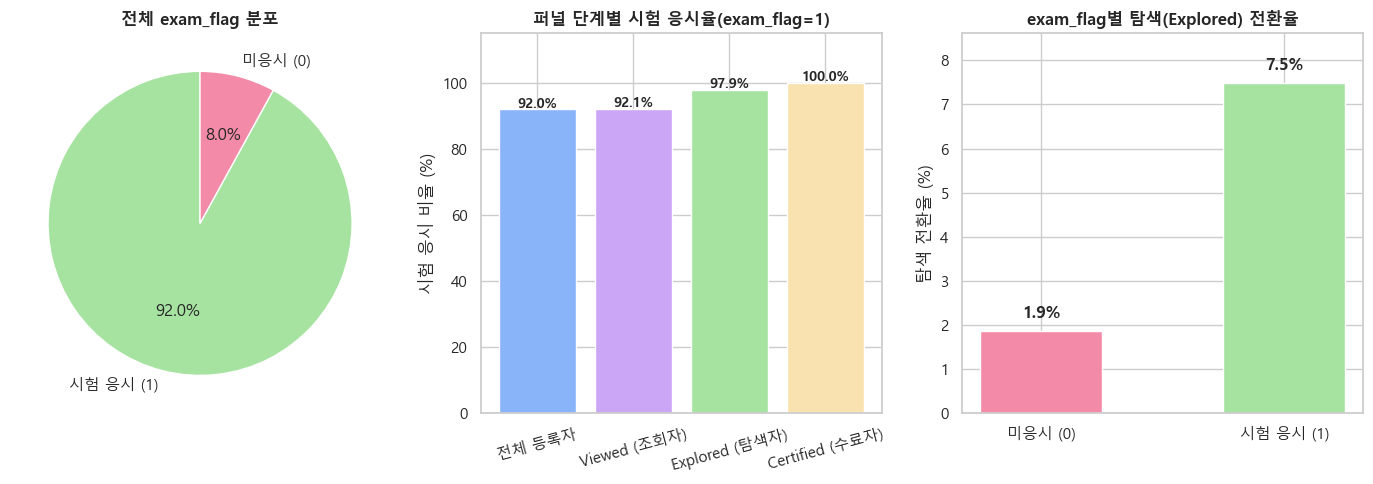


■ exam_flag 기본 현황 ■
- 전체 533,993명 중 시험 응시자(exam_flag=1): 491,268명 (92.0%)
- 미응시자(exam_flag=0): 42,725명 (8.0%)


In [239]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. 전체 exam_flag 분포 (파이차트)
flag_counts = df['exam_flag'].value_counts()
axes[0].pie(
    flag_counts,
    labels=['시험 응시 (1)', '미응시 (0)'],
    autopct='%1.1f%%',
    colors=['#a6e3a1', '#f38ba8'],
    startangle=90
)
axes[0].set_title('전체 exam_flag 분포', fontweight='bold')

# 2. 퍼널 단계별 exam_flag=1 비율
funnel_stages = {
    '전체 등록자': df,
    'Viewed (조회자)': df[df['viewed'] == 1],
    'Explored (탐색자)': df[df['explored'] == 1],
    'Certified (수료자)': df[df['certified'] == 1]
}

stage_names = list(funnel_stages.keys())
exam_rates = [data['exam_flag'].mean() * 100 for data in funnel_stages.values()]

bars = axes[1].bar(stage_names, exam_rates, color=['#89b4fa', '#cba6f7', '#a6e3a1', '#f9e2af'])
for bar, val in zip(bars, exam_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('퍼널 단계별 시험 응시율(exam_flag=1)', fontweight='bold')
axes[1].set_ylabel('시험 응시 비율 (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, max(exam_rates) * 1.15)

# 3. exam_flag × explored 교차 비율
cross = df.groupby('exam_flag')['explored'].mean() * 100
bars2 = axes[2].bar(['미응시 (0)', '시험 응시 (1)'], cross.values,
                     color=['#f38ba8', '#a6e3a1'], width=0.5)
for bar, val in zip(bars2, cross.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('exam_flag별 탐색(Explored) 전환율', fontweight='bold')
axes[2].set_ylabel('탐색 전환율 (%)')
axes[2].set_ylim(0, max(cross.values) * 1.15)

plt.tight_layout()
plt.show()

# 기술 통계 출력
print("\n■ exam_flag 기본 현황 ■")
print(f"- 전체 {len(df):,}명 중 시험 응시자(exam_flag=1): {flag_counts.get(1,0):,}명 ({flag_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"- 미응시자(exam_flag=0): {flag_counts.get(0,0):,}명 ({flag_counts.get(0,0)/len(df)*100:.1f}%)")


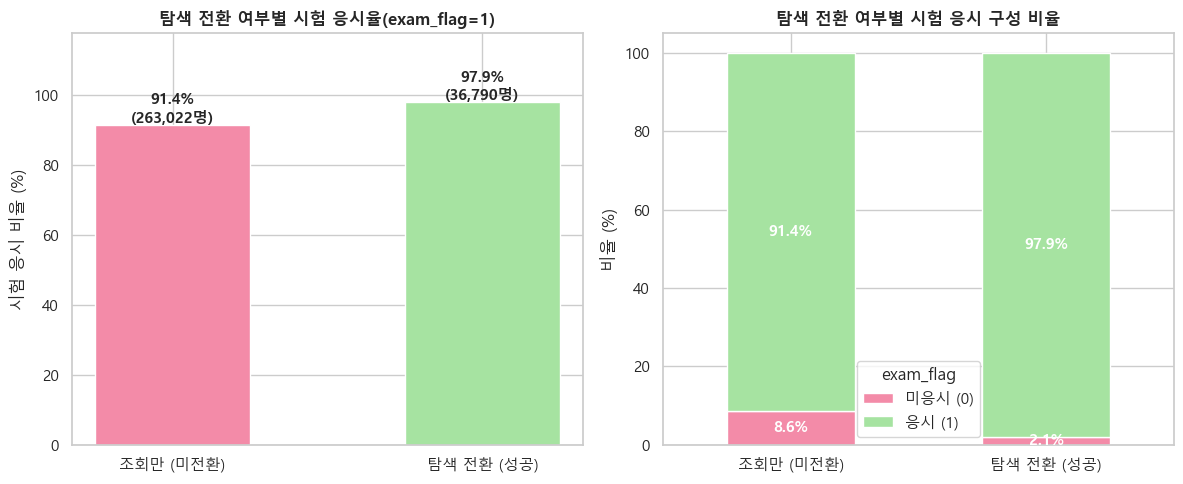


■ 카이제곱 검정 결과 ■
- P-value: 0.00000e+00
- Cramer's V (효과 크기): 0.077

⭐ 탐색 전환 여부와 시험 응시 여부는 통계적으로 유의미하게 연관됩니다!


In [240]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np

# 1. viewed 한 사람 기준으로 4개 그룹 생성
viewed_df = df[df['viewed'] == 1].copy()
viewed_df['group'] = '조회만 (미전환)'
viewed_df.loc[viewed_df['explored'] == 1, 'group'] = '탐색 전환 (성공)'

# 2. 그룹별 exam_flag=1 비율
cross = viewed_df.groupby('group')['exam_flag'].agg(['mean', 'sum', 'count']).reset_index()
cross.columns = ['group', 'exam_rate', 'exam_count', 'total']
cross['exam_rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3. 시험 응시율 비교 막대차트
bars = axes[0].bar(cross['group'], cross['exam_rate'],
                   color=['#f38ba8', '#a6e3a1'], width=0.5)
for bar, row in zip(bars, cross.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{row.exam_rate:.1f}%\n({row.exam_count:,}명)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('탐색 전환 여부별 시험 응시율(exam_flag=1)', fontweight='bold')
axes[0].set_ylabel('시험 응시 비율 (%)')
axes[0].set_ylim(0, max(cross['exam_rate']) * 1.2)

# 4. 스택 비율 차트 (exam_flag 0/1 구성 비율)
stack_data = viewed_df.groupby(['group', 'exam_flag']).size().unstack(fill_value=0)
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

stack_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#f38ba8', '#a6e3a1'], rot=0, width=0.5)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center',
                      fontweight='bold', color='white', fontsize=11)
axes[1].set_title('탐색 전환 여부별 시험 응시 구성 비율', fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xlabel('')
axes[1].legend(['미응시 (0)', '응시 (1)'], title='exam_flag')

plt.tight_layout()
plt.show()

# 5. 카이제곱 검정 (독립성 검정)
crosstab = pd.crosstab(viewed_df['group'], viewed_df['exam_flag'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

print("\n■ 카이제곱 검정 결과 ■")
print(f"- P-value: {p_val:.5e}")
print(f"- Cramer's V (효과 크기): {cramers_v:.3f}")
print(f"\n{'⭐ 탐색 전환 여부와 시험 응시 여부는 통계적으로 유의미하게 연관됩니다!' if p_val < 0.05 else '통계적으로 유의미한 차이 없음'}")


In [245]:
# 수료 여부와 exam_flag의 관계를 확인해보는 것이 더 흥미로울 수 있음
cross_cert = pd.crosstab(df['exam_flag'], df['certified'])
chi2, p_val, dof, expected = stats.chi2_contingency(cross_cert)
cramers_v_cert = np.sqrt(chi2 / (cross_cert.sum().sum() * (min(cross_cert.shape)-1)))
print(f"exam_flag × certified Cramer's V: {cramers_v_cert:.3f}")


exam_flag × certified Cramer's V: 0.055


In [242]:
# 이걸 확인해보시면 훨씬 강한 연관성이 나올 가능성이 높습니다
# grade(점수)가 임계값 이상인지 여부 × certified
df['pass_grade'] = (df['grade'].astype(float) >= 0.5).astype(int)


In [244]:
# 수료 여부와 exam_flag의 관계를 확인해보는 것이 더 흥미로울 수 있음
cross_cert = pd.crosstab(df['pass_grade'], df['certified'])
chi2, p_val, dof, expected = stats.chi2_contingency(cross_cert)
cramers_v_cert = np.sqrt(chi2 / (cross_cert.sum().sum() * (min(cross_cert.shape)-1)))
print(f"pass_grade × certified Cramer's V: {cramers_v_cert:.3f}")


pass_grade × certified Cramer's V: 0.966


Unknown/Other 집단: 49,202명 (전체의 9.2%)



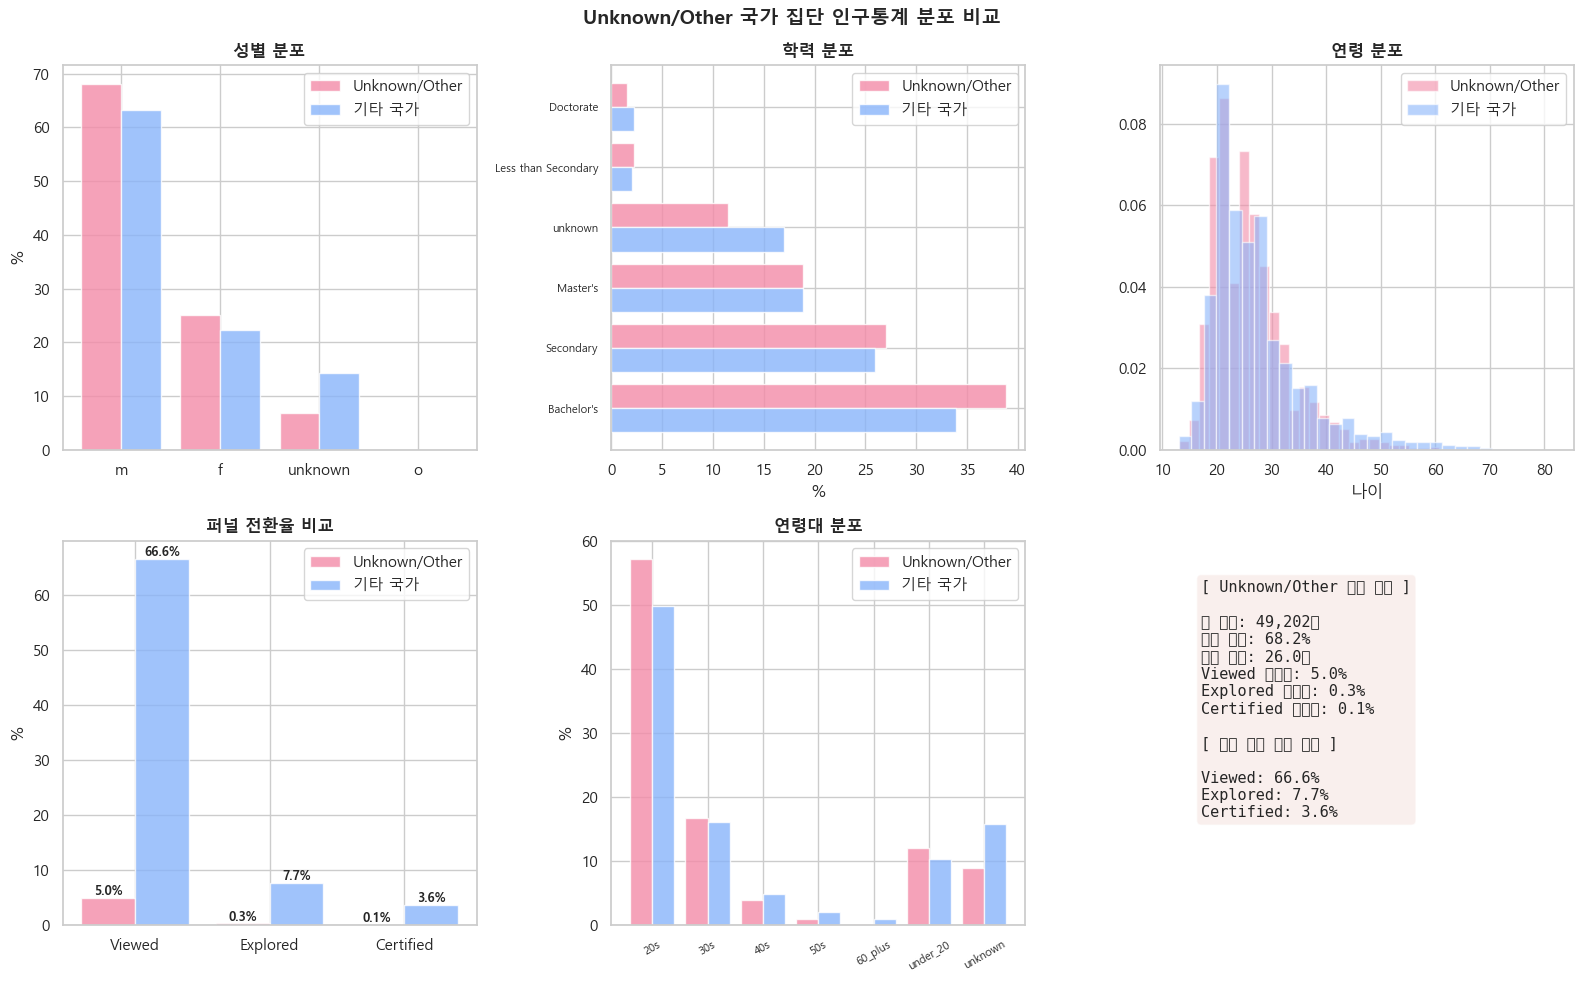

[ Unknown/Other 집단 요약 ]


총 인원: 49,202명

남성 비율: 68.2%

평균 나이: 26.0세

Viewed 전환율: 5.0%

Explored 전환율: 0.3%

Certified 전환율: 0.1%


[ 기타 국가 집단 대비 ]


Viewed: 66.6%

Explored: 7.7%

Certified: 3.6%


In [254]:
import matplotlib.pyplot as plt
import pandas as pd

# Unknown/Other 집단 분리
unknown_df = df[df['final_cc_cname_DI'] == 'Unknown/Other'].copy()
known_df = df[df['final_cc_cname_DI'] != 'Unknown/Other'].copy()

print(f"Unknown/Other 집단: {len(unknown_df):,}명 (전체의 {len(unknown_df)/len(df)*100:.1f}%)\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Unknown/Other 국가 집단 인구통계 분포 비교', fontweight='bold', fontsize=14)

# 1. 성별 분포
gender_unk = unknown_df['gender'].value_counts(normalize=True) * 100
gender_kno = known_df['gender'].value_counts(normalize=True) * 100
x = range(len(gender_unk))
axes[0,0].bar([i-0.2 for i in x], gender_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[0,0].bar([i+0.2 for i in x], gender_kno.reindex(gender_unk.index).values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(gender_unk.index)
axes[0,0].set_title('성별 분포', fontweight='bold'); axes[0,0].set_ylabel('%')
axes[0,0].legend()

# 2. 학력 분포
loe_unk = unknown_df['LoE_DI'].value_counts(normalize=True) * 100
loe_kno = known_df['LoE_DI'].value_counts(normalize=True) * 100
all_cats = loe_unk.index
axes[0,1].barh([i+0.2 for i in range(len(all_cats))], loe_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[0,1].barh([i-0.2 for i in range(len(all_cats))], loe_kno.reindex(all_cats).fillna(0).values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
axes[0,1].set_yticks(range(len(all_cats))); axes[0,1].set_yticklabels(all_cats, fontsize=8)
axes[0,1].set_title('학력 분포', fontweight='bold'); axes[0,1].set_xlabel('%')
axes[0,1].legend()

# 3. 연령 분포 (히스토그램)
axes[0,2].hist(unknown_df['age'].dropna(), bins=30, alpha=0.6, label='Unknown/Other', color='#f38ba8', density=True)
axes[0,2].hist(known_df['age'].dropna(), bins=30, alpha=0.6, label='기타 국가', color='#89b4fa', density=True)
axes[0,2].set_title('연령 분포', fontweight='bold'); axes[0,2].set_xlabel('나이')
axes[0,2].legend()

# 4. 퍼널 전환율 비교
metrics = ['viewed', 'explored', 'certified']
unk_rates = [unknown_df[m].mean()*100 for m in metrics]
kno_rates = [known_df[m].mean()*100 for m in metrics]
x2 = range(len(metrics))
axes[1,0].bar([i-0.2 for i in x2], unk_rates, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[1,0].bar([i+0.2 for i in x2], kno_rates, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
for i, (u, k) in enumerate(zip(unk_rates, kno_rates)):
    axes[1,0].text(i-0.2, u+0.5, f'{u:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1,0].text(i+0.2, k+0.5, f'{k:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1,0].set_xticks(x2); axes[1,0].set_xticklabels(['Viewed', 'Explored', 'Certified'])
axes[1,0].set_title('퍼널 전환율 비교', fontweight='bold'); axes[1,0].set_ylabel('%')
axes[1,0].legend()

# 5. 연령대 분포
age_unk = unknown_df['age_group'].value_counts(normalize=True).sort_index() * 100
age_kno = known_df['age_group'].value_counts(normalize=True).reindex(age_unk.index).fillna(0) * 100
axes[1,1].bar([i-0.2 for i in range(len(age_unk))], age_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[1,1].bar([i+0.2 for i in range(len(age_unk))], age_kno.values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
axes[1,1].set_xticks(range(len(age_unk))); axes[1,1].set_xticklabels(age_unk.index, rotation=30, fontsize=8)
axes[1,1].set_title('연령대 분포', fontweight='bold'); axes[1,1].set_ylabel('%')
axes[1,1].legend()

# 6. 기술 통계 요약 텍스트
axes[1,2].axis('off')
summary_text = (
    f"[ Unknown/Other 집단 요약 ]\n\n"
    f"총 인원: {len(unknown_df):,}명\n"
    f"남성 비율: {(unknown_df['gender']=='m').mean()*100:.1f}%\n"
    f"평균 나이: {unknown_df['age'].mean():.1f}세\n"
    f"Viewed 전환율: {unknown_df['viewed'].mean()*100:.1f}%\n"
    f"Explored 전환율: {unknown_df['explored'].mean()*100:.1f}%\n"
    f"Certified 전환율: {unknown_df['certified'].mean()*100:.1f}%\n\n"
    f"[ 기타 국가 집단 대비 ]\n\n"
    f"Viewed: {known_df['viewed'].mean()*100:.1f}%\n"
    f"Explored: {known_df['explored'].mean()*100:.1f}%\n"
    f"Certified: {known_df['certified'].mean()*100:.1f}%"
)
axes[1,2].text(0.1, 0.9, summary_text, transform=axes[1,2].transAxes,
               fontsize=11, va='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#f5e0dc', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"[ Unknown/Other 집단 요약 ]\n\n")
print(f"총 인원: {len(unknown_df):,}명\n")
print(f"남성 비율: {(unknown_df['gender']=='m').mean()*100:.1f}%\n")
print(f"평균 나이: {unknown_df['age'].mean():.1f}세\n")
print(f"Viewed 전환율: {unknown_df['viewed'].mean()*100:.1f}%\n")
print(f"Explored 전환율: {unknown_df['explored'].mean()*100:.1f}%\n")
print(f"Certified 전환율: {unknown_df['certified'].mean()*100:.1f}%\n\n")
print(f"[ 기타 국가 집단 대비 ]\n\n")
print(f"Viewed: {known_df['viewed'].mean()*100:.1f}%\n")
print(f"Explored: {known_df['explored'].mean()*100:.1f}%\n")
print(f"Certified: {known_df['certified'].mean()*100:.1f}%")

■ 인구통계 컬럼별 결측치 비율 비교 ■


,Unknown/Other (%),기타 국가 (%)
age,9.0000,15.8000
gender,0.0000,0.0000
LoE_DI,0.0000,0.0000
YoB,9.0000,15.8000


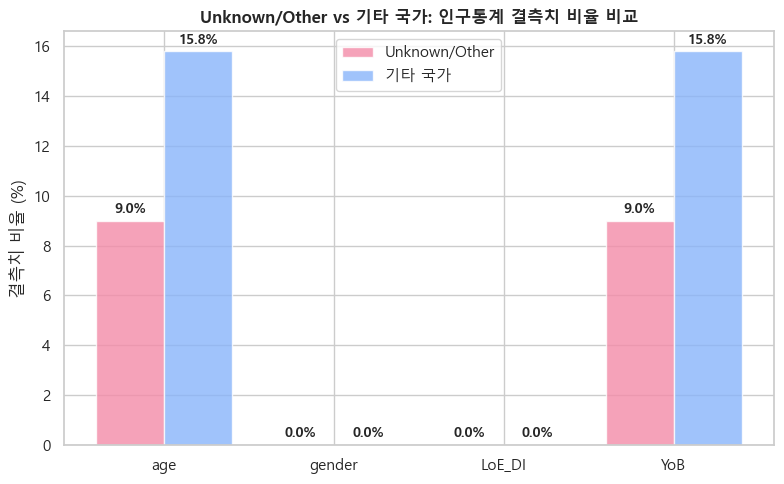

In [304]:
import pandas as pd
import matplotlib.pyplot as plt

# Unknown/Other vs 기타 국가 분리
unknown_df = df[df['final_cc_cname_DI'] == 'Unknown/Other'].copy()
known_df = df[df['final_cc_cname_DI'] != 'Unknown/Other'].copy()

# 인구통계 컬럼만 선택
demo_cols = ['age', 'gender', 'LoE_DI', 'YoB']

# 결측치 비율 계산
missing_unk = unknown_df[demo_cols].isnull().mean() * 100
missing_kno = known_df[demo_cols].isnull().mean() * 100

# 비교 데이터프레임
missing_compare = pd.DataFrame({
    'Unknown/Other (%)': missing_unk,
    '기타 국가 (%)': missing_kno
}).round(1)

print("■ 인구통계 컬럼별 결측치 비율 비교 ■")
display(missing_compare)

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(demo_cols))
ax.bar([i-0.2 for i in x], missing_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
ax.bar([i+0.2 for i in x], missing_kno.values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)

for i, (u, k) in enumerate(zip(missing_unk.values, missing_kno.values)):
    ax.text(i-0.2, u+0.3, f'{u:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(i+0.2, k+0.3, f'{k:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(demo_cols)
ax.set_title('Unknown/Other vs 기타 국가: 인구통계 결측치 비율 비교', fontweight='bold')
ax.set_ylabel('결측치 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()


In [256]:
df['final_cc_cname_DI'].value_counts()

final_cc_cname_DI
United States                             155616
India                                      79044
Unknown/Other                              49202
Other Europe                               35434
Other Africa                               20942
United Kingdom                             19195
Brazil                                     15978
Other Middle East/Central Asia             15380
Other South Asia                           11415
Canada                                     10605
Pakistan                                    9323
Russian Federation                          9033
Other South America                         8766
Spain                                       8741
Egypt                                       8241
Germany                                     7223
Nigeria                                     6335
Other East Asia                             5730
Australia                                   5481
Mexico                                      4946
Ch

## high risk/normal 집단 exp 전환율 비교

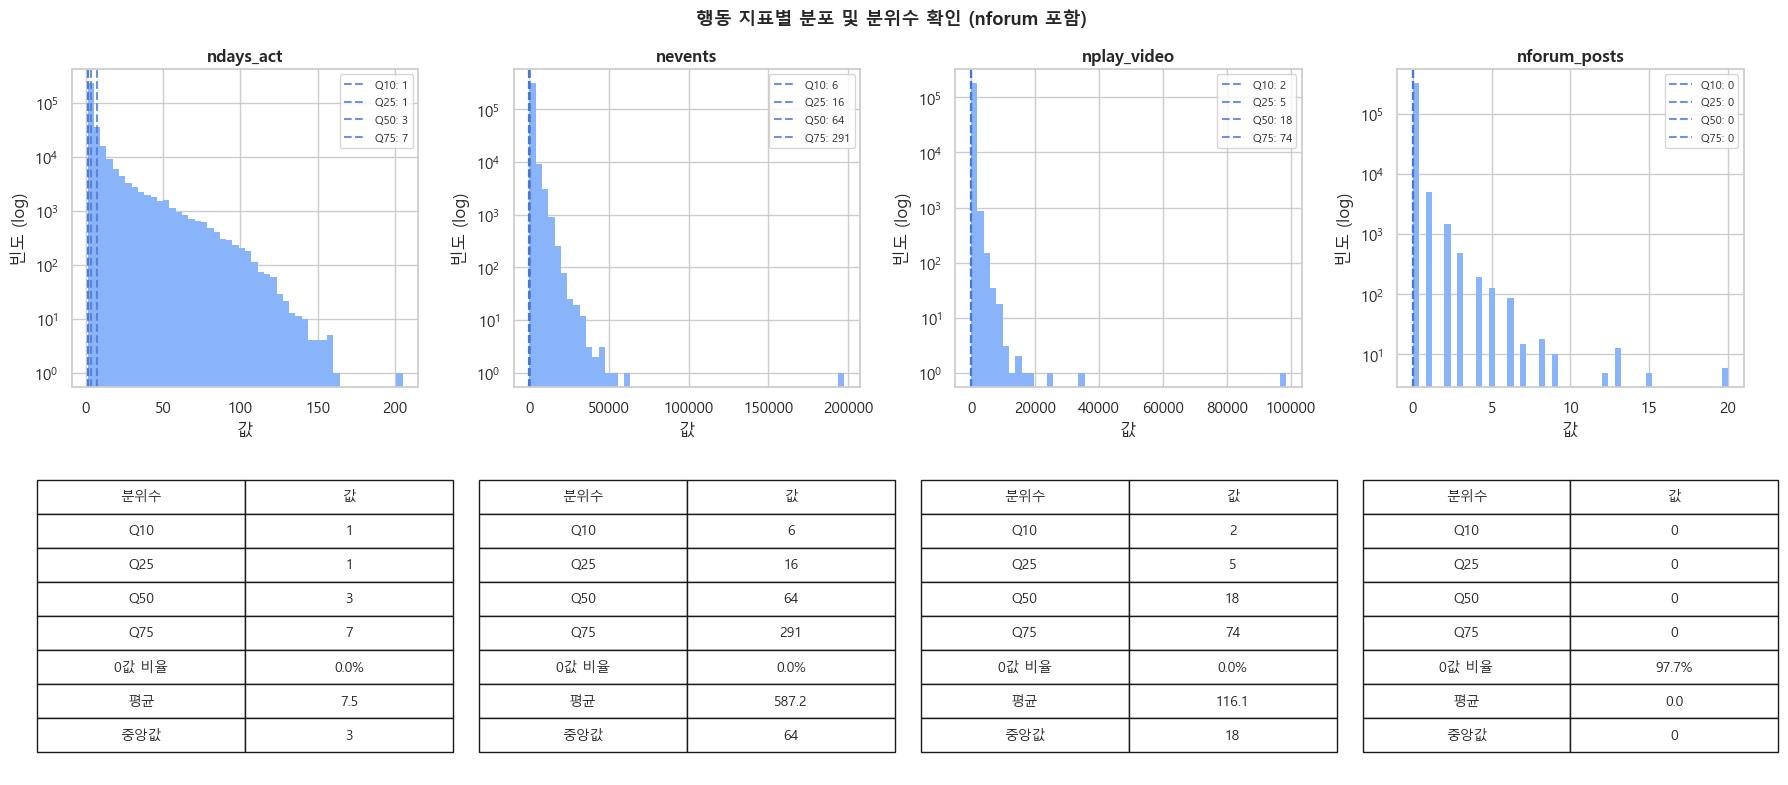

In [294]:
import matplotlib.pyplot as plt

viewed_df = df[df['viewed'] == 1].copy()
cols = ['ndays_act', 'nevents', 'nplay_video', 'nforum_posts']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
quantiles = [0.10, 0.25, 0.50, 0.75]

for i, col in enumerate(cols):
    data = viewed_df[col].dropna()

    axes[0, i].hist(data, bins=50, color='#89b4fa', log=True, edgecolor='none')
    for q in quantiles:
        val = data.quantile(q)
        axes[0, i].axvline(val, linestyle='--', alpha=0.8, label=f'Q{int(q*100)}: {val:.0f}')
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_xlabel('값')
    axes[0, i].set_ylabel('빈도 (log)')
    axes[0, i].legend(fontsize=8)

    axes[1, i].axis('off')
    q_vals = data.quantile(quantiles).round(1)
    zero_pct = (data == 0).mean() * 100
    table_data = [[f'Q{int(q*100)}', f'{v:.0f}'] for q, v in zip(quantiles, q_vals)] + \
                 [['0값 비율', f'{zero_pct:.1f}%']] + \
                 [['평균', f'{data.mean():.1f}'], ['중앙값', f'{data.median():.0f}']]
    table = axes[1, i].table(cellText=table_data, colLabels=['분위수', '값'],
                              loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)

plt.suptitle('행동 지표별 분포 및 분위수 확인 (nforum 포함)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


ndays의 경우 q25까지 전부 1 -> q50 사용 고려    
통계검정!

In [287]:
from scipy import stats
import numpy as np

viewed_df = df[df['viewed'] == 1].copy()

q25 = viewed_df['ndays_act'].quantile(0.25)  # = 1일
q50 = viewed_df['ndays_act'].quantile(0.50)  # = 3일

# Q25 기준으로 분류
viewed_df['risk_q25'] = (viewed_df['ndays_act'] <= q25).astype(int)
# Q50 기준으로 분류
viewed_df['risk_q50'] = (viewed_df['ndays_act'] <= q50).astype(int)

print(f"■ ndays_act 기준값: Q25={q25:.0f}일, Q50={q50:.0f}일\n")

for label, col in [('Q25 기준 (≤1일)', 'risk_q25'), ('Q50 기준 (≤3일)', 'risk_q50')]:
    high = viewed_df[viewed_df[col] == 1]['explored']
    low  = viewed_df[viewed_df[col] == 0]['explored']
    
    high_rate = high.mean() * 100
    low_rate  = low.mean()  * 100
    
    # 카이제곱 검정
    crosstab = pd.crosstab(viewed_df[col], viewed_df['explored'])
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))
    
    print(f"[{label}]")
    print(f"  High Risk 집단 탐색 전환율: {high_rate:.2f}% ({len(high):,}명)")
    print(f"  Low Risk  집단 탐색 전환율: {low_rate:.2f}%  ({len(low):,}명)")
    print(f"  P-value: {p_val:.5e} | Cramer's V: {cramers_v:.3f}")
    print()


■ ndays_act 기준값: Q25=1일, Q50=3일

[Q25 기준 (≤1일)]
  High Risk 집단 탐색 전환율: 1.47% (93,002명)
  Low Risk  집단 탐색 전환율: 15.59%  (232,359명)
  P-value: 0.00000e+00 | Cramer's V: 0.200

[Q50 기준 (≤3일)]
  High Risk 집단 탐색 전환율: 1.83% (188,528명)
  Low Risk  집단 탐색 전환율: 24.95%  (136,833명)
  P-value: 0.00000e+00 | Cramer's V: 0.357



q50(3일 기준)이 exp 전환율에 더 유의미한 효과크기를 보임

In [291]:
# 각 조건 충족 시 1점씩 부여 → 3점 이상이면 High Risk
viewed_df['risk_score'] = (
    (viewed_df['ndays_act'] <= 3).astype(int) +
    (viewed_df['nevents'] <= 16).astype(int) +
    (viewed_df['nplay_video'] <= 5).astype(int) +
    (viewed_df['nforum_posts'] == 0).astype(int)
)
viewed_df['high_risk'] = (viewed_df['risk_score'] >= 3).astype(int)

print(f"High Risk 집단: {viewed_df['high_risk'].sum():,}명 ({viewed_df['high_risk'].mean()*100:.1f}%)")
print(f"Low Risk 집단: {(viewed_df['high_risk']==0).sum():,}명 ({(viewed_df['high_risk']==0).mean()*100:.1f}%)")

High Risk 집단: 101,973명 (31.3%)
Low Risk 집단: 223,388명 (68.7%)


In [ ]:
# high_risk 분류 (이전 셀이 실행된 상태)
high_risk_group = viewed_df[viewed_df['high_risk'] == 1]['explored']
low_risk_group  = viewed_df[viewed_df['high_risk'] == 0]['explored']

# 1. 전환율 비교
high_rate = high_risk_group.mean() * 100
low_rate  = low_risk_group.mean()  * 100

print("■ High Risk vs Low Risk 탐색(Explored) 전환율 비교 ■\n")
print(f"  High Risk 집단: {high_rate:.2f}%  ({viewed_df['high_risk'].sum():,}명)")
print(f"  Low Risk  집단: {low_rate:.2f}%  ({(viewed_df['high_risk']==0).sum():,}명)")
print(f"  전환율 차이(Gap): {low_rate - high_rate:.2f}%p\n")

# 2. 카이제곱 검정 + Cramer's V
crosstab = pd.crosstab(viewed_df['high_risk'], viewed_df['explored'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

# 3. Odds Ratio
a = crosstab.loc[1, 1]  # high_risk=1, explored=1
b = crosstab.loc[1, 0]  # high_risk=1, explored=0
c = crosstab.loc[0, 1]  # high_risk=0, explored=1
d = crosstab.loc[0, 0]  # high_risk=0, explored=0
odds_ratio = (a * d) / (b * c)

print("■ 통계 검정 결과 ■\n")
print(f"  P-value:     {p_val:.5e}")
print(f"  Cramer's V:  {cramers_v:.3f}  {'🔥 Large' if cramers_v>=0.5 else '🔸 Medium' if cramers_v>=0.3 else '🔹 Small' if cramers_v>=0.1 else '💧 Trivial'}")
print(f"  Odds Ratio:  {odds_ratio:.3f}배  (1보다 클수록 Low Risk가 탐색 전환에 유리)")


■ High Risk vs Low Risk 탐색(Explored) 전환율 비교 ■

  High Risk 집단: 1.48%  (101,973명)
  Low Risk  집단: 16.15%  (223,388명)
  전환율 차이(Gap): 14.67%p

■ 통계 검정 결과 ■

  P-value:     0.00000e+00
  Cramer's V:  0.213  🔹 Small
  Odds Ratio:  0.078배  (1보다 클수록 Low Risk가 탐색 전환에 유리)


In [295]:
import pandas as pd
import numpy as np
from scipy import stats

viewed_df = df[df['viewed'] == 1].copy()

# 임계값 정의
thresholds = {
    'ndays_act':    ('<=', 3),
    'nevents':      ('<=', 16),
    'nplay_video':  ('<=', 5),
    'nforum_posts': ('==', 0),
}

# 점수제 high_risk (3점 이상)
viewed_df['risk_score'] = sum([
    (viewed_df['ndays_act'] <= 3).astype(int),
    (viewed_df['nevents'] <= 16).astype(int),
    (viewed_df['nplay_video'] <= 5).astype(int),
    (viewed_df['nforum_posts'] == 0).astype(int)
])
viewed_df['high_risk_score'] = (viewed_df['risk_score'] >= 3).astype(int)

results = []

# 1. 각 변수 개별 검정
for col, (op, val) in thresholds.items():
    if op == '<=':
        flag = (viewed_df[col] <= val).astype(int)
    else:
        flag = (viewed_df[col] == val).astype(int)

    high_rate = viewed_df[flag == 1]['explored'].mean() * 100
    low_rate  = viewed_df[flag == 0]['explored'].mean() * 100

    crosstab = pd.crosstab(flag, viewed_df['explored'])
    chi2, p_val, _, _ = stats.chi2_contingency(crosstab)
    cv = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

    results.append({
        '기준': f'{col} {op} {val}',
        'High Risk N': f"{flag.sum():,}명",
        'High Risk 전환율(%)': round(high_rate, 2),
        'Low Risk 전환율(%)': round(low_rate, 2),
        '전환율 Gap(%p)': round(low_rate - high_rate, 2),
        'Cramer\'s V': round(cv, 3),
        '효과 크기': '🔥Large' if cv>=0.5 else '🔸Medium' if cv>=0.3 else '🔹Small' if cv>=0.1 else '💧Trivial'
    })

# 2. 점수제 결과 추가
flag_s = viewed_df['high_risk_score']
high_rate_s = viewed_df[flag_s==1]['explored'].mean() * 100
low_rate_s  = viewed_df[flag_s==0]['explored'].mean() * 100
crosstab_s = pd.crosstab(flag_s, viewed_df['explored'])
chi2_s, p_s, _, _ = stats.chi2_contingency(crosstab_s)
cv_s = np.sqrt(chi2_s / (crosstab_s.sum().sum() * (min(crosstab_s.shape) - 1)))

results.append({
    '기준': '점수제 (4개 중 3개 이상)',
    'High Risk N': f"{flag_s.sum():,}명",
    'High Risk 전환율(%)': round(high_rate_s, 2),
    'Low Risk 전환율(%)': round(low_rate_s, 2),
    '전환율 Gap(%p)': round(low_rate_s - high_rate_s, 2),
    'Cramer\'s V': round(cv_s, 3),
    '효과 크기': '🔥Large' if cv_s>=0.5 else '🔸Medium' if cv_s>=0.3 else '🔹Small' if cv_s>=0.1 else '💧Trivial'
})

display(pd.DataFrame(results).set_index('기준'))


,High Risk N,High Risk 전환율(%),Low Risk 전환율(%),전환율 Gap(%p),Cramer's V,효과 크기
기준,,,,,,
ndays_act <= 3,"188,528명",1.8300,24.9500,23.1200,0.3570,🔸Medium
nevents <= 16,"82,481명",1.9300,14.8200,12.8800,0.1750,🔹Small
nplay_video <= 5,"48,256명",2.0800,13.2000,11.1200,0.1240,🔹Small
nforum_posts == 0,"318,003명",10.9500,37.4700,26.5200,0.1230,🔹Small
점수제 (4개 중 3개 이상),"101,973명",1.4800,16.1500,14.6700,0.2130,🔹Small


In [296]:
# 조회자(viewed=1) 전체 기준 탐색(explored) 전환율
viewed_df = df[df['viewed'] == 1].copy()

total = len(viewed_df)
explored = viewed_df['explored'].sum()
rate = explored / total * 100

print(f"조회자 전체: {total:,}명")
print(f"탐색 전환자: {explored:,}명")
print(f"조회 → 탐색 전환율: {rate:.2f}%")


조회자 전체: 325,361명
탐색 전환자: 37,584명
조회 → 탐색 전환율: 11.55%


In [298]:
from statsmodels.stats.proportion import proportions_ztest

viewed_df = df[df['viewed'] == 1].copy()

# high_risk_score 재생성
viewed_df['risk_score'] = (
    (viewed_df['ndays_act'] <= 3).astype(int) +
    (viewed_df['nevents'] <= 16).astype(int) +
    (viewed_df['nplay_video'] <= 5).astype(int) +
    (viewed_df['nforum_posts'] == 0).astype(int)
)
viewed_df['high_risk_score'] = (viewed_df['risk_score'] >= 3).astype(int)

baseline_rate = 37584 / 325361  # 전체 평균 11.55%

for label, cond in [('High Risk (위험군)', viewed_df['high_risk_score'] == 1),
                     ('Low Risk (안전군)',  viewed_df['high_risk_score'] == 0)]:
    group = viewed_df[cond]
    n = len(group)
    k = group['explored'].sum()
    rate = k / n * 100

    stat, p_val = proportions_ztest(
        count=k, nobs=n, value=baseline_rate,
        alternative='smaller' if 'High' in label else 'larger'
    )
    direction = "낮음(이탈위험)" if 'High' in label else "높음(우수)"
    sig = "✅ 유의미" if p_val < 0.05 else "❌ 차이없음"

    print(f"[{label}]")
    print(f"  전환율: {rate:.2f}% (베이스라인 11.55% 대비 {rate-11.55:+.2f}%p)")
    print(f"  P-value: {p_val:.5e} → {sig} ({direction})\n")


[High Risk (위험군)]
  전환율: 1.48% (베이스라인 11.55% 대비 -10.07%p)
  P-value: 0.00000e+00 → ✅ 유의미 (낮음(이탈위험))

[Low Risk (안전군)]
  전환율: 16.15% (베이스라인 11.55% 대비 +4.60%p)
  P-value: 0.00000e+00 → ✅ 유의미 (높음(우수))



In [299]:
import numpy as np

def cohens_h(p1, p2):
    """두 비율 간 Cohen's h 효과 크기"""
    return abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))

baseline_rate = 37584 / 325361

for label, cond in [('High Risk (위험군)', viewed_df['high_risk_score'] == 1),
                     ('Low Risk (안전군)',  viewed_df['high_risk_score'] == 0)]:
    group = viewed_df[cond]
    rate = group['explored'].mean()
    h = cohens_h(rate, baseline_rate)

    if h >= 0.8:   level = "Large 🔥"
    elif h >= 0.5: level = "Medium 🔸"
    elif h >= 0.2: level = "Small 🔹"
    else:          level = "Trivial 💧"

    print(f"[{label}]")
    print(f"  전환율: {rate*100:.2f}% vs 베이스라인 {baseline_rate*100:.2f}%")
    print(f"  Cohen's h: {h:.3f} → {level}\n")


[High Risk (위험군)]
  전환율: 1.48% vs 베이스라인 11.55%
  Cohen's h: 0.450 → Small 🔹

[Low Risk (안전군)]
  전환율: 16.15% vs 베이스라인 11.55%
  Cohen's h: 0.134 → Trivial 💧



# 규리님 윤범님 아이디어 올라타기